# Phase 4 - Blockchain + Encryption (Tamper-Proof Security Layer)
## Secure AI-Based Handwritten Text Recognition for Indian Scripts

### Abstract alignment:
> Each recognized text output will be hashed and stored on a private blockchain,
> ensuring tamper-proof verification. Sensitive data is further protected using
> AES-256 encryption. Digital watermarking provides an additional layer of
> authenticity verification.

### What this notebook builds (core abstract features):
1. A lightweight private blockchain (linked blocks, each storing the previous
   block's hash - the standard blockchain tamper-evidence mechanism)
2. SHA-256 hashing of every recognized text output (from Phase 2/3 predictions)
3. AES-256 encryption of the actual recognized text content
4. A tamper-detection demonstration - showing that any modification to stored
   data is immediately detectable via hash mismatch
5. A verification utility that any later phase (or the Streamlit app) can call
   to check whether a piece of recognized text matches its blockchain record

### Defense-in-depth additions (beyond the minimum abstract wording - this is a
### cybersecurity-focused project, so we deliberately do not stop at the bare
### minimum):
6. **Digital signatures (RSA-2048)** on every block - proves WHO created a
   record, not just that it's unmodified. Hashing alone proves integrity;
   signing proves authenticity/non-repudiation.
7. **Invisible digital watermarking** embedded into a visual representation of
   each secured record - an extra authenticity layer independent of the
   blockchain/encryption path, as called out in the abstract.
8. **Role-Based Access Control (RBAC) simulation** - models who is allowed to
   view plaintext vs. only verify integrity (Admin / Verifier / Viewer), since
   a real secure document vault is multi-user, not single-user.

### Resumable + RAM-safe:
- Works off a bounded sample of test predictions (not the full dataset) - this
  is intentionally lightweight since blockchain hashing operates on recognized
  TEXT OUTPUTS, not on raw images.
- Blocks are appended to disk in chunks and the chain file is never fully
  reloaded into memory more than once per run.

### Builds on:
- Phase 2 `model_best.pth` + Phase 1 `processed/test/` (to get real recognized
  text samples to secure)

---
## Cell 1 - Install Dependencies

In [3]:
import subprocess, sys

def pip(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

# Separating installations. Torch and torchvision are often pre-installed
# and optimized in Colab; reinstalling them can cause conflicts.
pip('opencv-python-headless')
pip('cryptography')
pip('pandas')
pip('psutil')

import torch, sys, platform
print('✅ Dependencies installed!')
print(f'   Python   : {sys.version.split()[0]}')
print(f'   PyTorch  : {torch.__version__}')
print(f'   CUDA     : {torch.version.cuda}')
print(f'   Platform : {platform.platform()}')

✅ Dependencies installed!
   Python   : 3.12.13
   PyTorch  : 2.11.0+cu128
   CUDA     : 12.8
   Platform : Linux-6.6.122+-x86_64-with-glibc2.35


---
## Cell 2 - Imports

In [4]:
# ============================================
# CELL 2 - Imports
# ============================================
import os, gc, json, hashlib, base64, random, uuid, secrets
import datetime, time, warnings, logging
import numpy as np
import pandas as pd
import psutil
from pathlib import Path
from tqdm import tqdm
from typing import Dict, List, Tuple, Optional
import cv2

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from cryptography.hazmat.primitives.ciphers import Cipher, algorithms, modes
from cryptography.hazmat.primitives import padding as sym_padding
from cryptography.hazmat.primitives.kdf.pbkdf2 import PBKDF2HMAC
from cryptography.hazmat.primitives import hashes as crypto_hashes
from cryptography.hazmat.primitives.asymmetric import rsa, padding as asym_padding
from cryptography.hazmat.primitives.serialization import (
    Encoding, PrivateFormat, PublicFormat, NoEncryption,
    load_pem_private_key, load_pem_public_key)
import os as _os

warnings.filterwarnings('ignore')

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s [%(levelname)s] %(message)s',
    handlers=[logging.StreamHandler()]
)
logger = logging.getLogger('Phase4')

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SESSION_ID = str(uuid.uuid4())[:8]

print(f'Device     : {DEVICE}')
print(f'Session ID : {SESSION_ID}')
if torch.cuda.is_available():
    print(f'   GPU  : {torch.cuda.get_device_name(0)}')
    print(f'   VRAM : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
print(f'   RAM  : {psutil.virtual_memory().total/1e9:.1f} GB')
logger.info(f'Phase 4 session {SESSION_ID} started')

Device     : cuda
Session ID : 6cc6c49d
   GPU  : Tesla T4
   VRAM : 15.6 GB
   RAM  : 13.6 GB


---
## Cell 3 - Drive Mount + Paths (standard block - same across all phases)

In [5]:
# ============================================
# CELL 3 - Drive Mount + Paths
# ============================================
from google.colab import drive
drive.mount('/content/drive')

PROJECT_VERSION  = 'SecureIndicHTR-v1.0'
EXECUTION_START  = time.time()
EXECUTION_TS     = datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')

BASE_DIR       = Path('/content/drive/MyDrive/OCR_Project')
RAW_DIR        = BASE_DIR / 'raw'
DATA_DIR       = BASE_DIR / 'processed'
MODEL_DIR      = BASE_DIR / 'models'
LOG_DIR        = BASE_DIR / 'logs'
OUT_DIR        = BASE_DIR / 'outputs'
BLOCKCHAIN_DIR = BASE_DIR / 'blockchain'

TRAIN_DIR  = DATA_DIR / 'train'
VAL_DIR    = DATA_DIR / 'val'
TEST_DIR   = DATA_DIR / 'test'
FINAL_DIR  = MODEL_DIR / 'final'
FL_DIR     = MODEL_DIR / 'federated'

# All output subdirs
for d in [
    BLOCKCHAIN_DIR,
    OUT_DIR / 'evaluation',
    OUT_DIR / 'evaluation' / 'figures',
    OUT_DIR / 'reports',
    OUT_DIR / 'metrics',
    OUT_DIR / 'security',
    OUT_DIR / 'exports',
]:
    d.mkdir(parents=True, exist_ok=True)

# Session metadata
session_meta = {
    'project'       : PROJECT_VERSION,
    'session_id'    : SESSION_ID,
    'timestamp'     : EXECUTION_TS,
    'device'        : str(DEVICE),
    'python_version': sys.version.split()[0],
    'torch_version' : torch.__version__,
    'cuda_available': torch.cuda.is_available(),
    'ram_gb'        : round(psutil.virtual_memory().total/1e9, 1),
}
with open(OUT_DIR / 'metrics' / 'phase4_session_meta.json', 'w') as f:
    json.dump(session_meta, f, indent=2)

print('✅ Drive mounted + all directories created!')
print(f'   Project  : {PROJECT_VERSION}')
print(f'   Session  : {SESSION_ID}')
print(f'   Started  : {EXECUTION_TS}')
print(f'   Blockchain dir: {BLOCKCHAIN_DIR}')
logger.info('Paths + directories ready')

Mounted at /content/drive
✅ Drive mounted + all directories created!
   Project  : SecureIndicHTR-v1.0
   Session  : 6cc6c49d
   Started  : 2026-06-27 13:11:29
   Blockchain dir: /content/drive/MyDrive/OCR_Project/blockchain


---
## Cell 4 - Load Trained Model (prefers Phase 3 FL model, falls back to Phase 2)

In [6]:
# ============================================
# CELL 4 - Load Trained Model
# ============================================
with open(MODEL_DIR / 'label_map.json', 'r') as f:
    label_data = json.load(f)

label2idx   = label_data['label2idx']
idx2label   = {int(k): v for k, v in label_data['idx2label'].items()}
NUM_CLASSES = label_data['num_classes']
print(f'Label map loaded! Classes: {NUM_CLASSES}')

class CNN_BiLSTM_CTC(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 64, 3, padding=1), nn.BatchNorm2d(64), nn.GELU(), nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.GELU(), nn.MaxPool2d(2, 2),
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.GELU(),
            nn.Conv2d(256, 256, 3, padding=1), nn.BatchNorm2d(256), nn.GELU(), nn.MaxPool2d((2,1),(2,1)),
            nn.Conv2d(256, 512, 3, padding=1), nn.BatchNorm2d(512), nn.GELU(),
            nn.Conv2d(512, 512, 3, padding=1), nn.BatchNorm2d(512), nn.GELU(), nn.MaxPool2d((2,1),(2,1)),
            nn.Dropout2d(0.30)
        )
        self.bilstm    = nn.LSTM(512*4, 256, num_layers=2, bidirectional=True, batch_first=True, dropout=0.30)
        self.layer_norm = nn.LayerNorm(512)
        self.fc         = nn.Linear(512, num_classes + 1)
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out')
                if m.bias is not None: nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        f = self.cnn(x)
        B, C, H, W = f.size()
        f = f.permute(0,3,1,2).reshape(B, W, C*H)
        f, _ = self.bilstm(f)
        f = self.layer_norm(f)
        return self.fc(f).permute(1, 0, 2)

model = CNN_BiLSTM_CTC(NUM_CLASSES).to(DEVICE)

t_load          = time.time()
fl_model_path   = FL_DIR   / 'fl_global_model_final.pth'
best_model_path = FINAL_DIR / 'model_best.pth'
model_source    = None

if fl_model_path.exists():
    checkpoint = torch.load(fl_model_path, map_location=DEVICE)
    model.load_state_dict(checkpoint['model_state'])
    model_source = 'Phase 3 FL'
    print('✅ Phase 3 FL model loaded!')
elif best_model_path.exists():
    checkpoint = torch.load(best_model_path, map_location=DEVICE)
    model.load_state_dict(checkpoint['model_state'])
    model_source = 'Phase 2'
    print('✅ Phase 2 model loaded (fallback)!')
    print(f'   val_acc : {checkpoint["val_acc"]:.4f}')
    print(f'   best_acc: {checkpoint.get("best_acc", 0.0):.4f}')
else:
    raise FileNotFoundError('No trained model found! Run Phase 2 first.')

load_time    = time.time() - t_load
model.eval()
del checkpoint

total_params  = sum(p.numel() for p in model.parameters())
model_size_mb = total_params * 4 / 1e6
active_path   = fl_model_path if fl_model_path.exists() else best_model_path
model_sha256  = hashlib.sha256(open(active_path, 'rb').read()).hexdigest()

# ── NEW: Parameter checksum ─────────────────────
param_bytes  = b''.join(p.data.cpu().numpy().tobytes() for p in model.parameters())
param_chksum = hashlib.sha256(param_bytes).hexdigest()
del param_bytes

model_meta = {
    'source'          : model_source,
    'architecture'    : 'CNN_BiLSTM_CTC',          # ← NEW
    'path'            : str(active_path),
    'sha256'          : model_sha256,
    'param_checksum'  : param_chksum,               # ← NEW
    'total_params'    : total_params,
    'model_size_mb'   : round(model_size_mb, 2),
    'load_time_ms'    : round(load_time*1000, 1),   # ← NEW: ms unit
    'load_benchmark'  : f'{load_time*1000:.1f} ms', # ← NEW
    'num_classes'     : NUM_CLASSES,
    'device'          : str(DEVICE),
    'ram_used_mb'     : round(psutil.virtual_memory().used/1e6, 1),
}
with open(OUT_DIR / 'metrics' / 'phase4_model_meta.json', 'w') as f:
    json.dump(model_meta, f, indent=2)

print(f'\nModel Info:')
print(f'   Source           : {model_source}')
print(f'   Architecture     : CNN_BiLSTM_CTC')
print(f'   Total Params     : {total_params:,}')
print(f'   Model Size       : {model_size_mb:.1f} MB (fp32)')
print(f'   Load Time        : {load_time*1000:.1f} ms')
print(f'   SHA256           : {model_sha256[:24]}...')
print(f'   Param Checksum   : {param_chksum[:24]}...')
print(f'   RAM Used         : {psutil.virtual_memory().used/1e6:.0f} MB')
print(f'   Device           : {DEVICE}')
logger.info(f'Model loaded from {model_source} | SHA256: {model_sha256[:16]}...')

Label map loaded! Classes: 427
✅ Phase 3 FL model loaded!

Model Info:
   Source           : Phase 3 FL
   Architecture     : CNN_BiLSTM_CTC
   Total Params     : 11,023,404
   Model Size       : 44.1 MB (fp32)
   Load Time        : 5112.5 ms
   SHA256           : aba254fc8e22766ce8026fd2...
   Param Checksum   : 844e04f790fa364f6a85c572...
   RAM Used         : 1684 MB
   Device           : cuda


---
## Cell 5 - Generate Recognized Text Records (small bounded sample, RAM-safe)

Blockchain hashing operates on the model's TEXT OUTPUT, not on raw images, so we
only need a modest sample of test predictions here (not the full 150K+ test set).
`SAMPLE_SIZE` keeps this fast and RAM-light while still giving a meaningful
demonstration set for hashing, encryption, and tamper-detection.

In [7]:
# ============================================
# EXTRACT ALL TAR FILES TO LOCAL SSD
# ============================================

!rm -rf /content/processed_local

!mkdir -p /content/processed_local/train
!mkdir -p /content/processed_local/val
!mkdir -p /content/processed_local/test

# -------------------------
# TRAIN
# -------------------------

!tar -xf /content/drive/MyDrive/OCR_Project/train_hindi.tar \
-C /content/processed_local/train

!tar -xf /content/drive/MyDrive/OCR_Project/train_telugu.tar \
-C /content/processed_local/train

# -------------------------
# VAL
# -------------------------

!tar -xf /content/drive/MyDrive/OCR_Project/val_hindi.tar \
-C /content/processed_local/val

!tar -xf /content/drive/MyDrive/OCR_Project/val_telugu.tar \
-C /content/processed_local/val

# -------------------------
# TEST
# -------------------------

!tar -xf /content/drive/MyDrive/OCR_Project/test_hindi.tar \
-C /content/processed_local/test

!tar -xf /content/drive/MyDrive/OCR_Project/test_telugu.tar \
-C /content/processed_local/test

print("All TAR files extracted successfully!")

All TAR files extracted successfully!


In [8]:
# ============================================
# VERIFY LOCAL DATASET
# ============================================

!find /content/processed_local/train -type f | wc -l
!find /content/processed_local/val   -type f | wc -l
!find /content/processed_local/test  -type f | wc -l

709214
151708
151706


Data source: LOCAL SSD ✅
   Path: /content/processed_local
   Indexed 151,706 test files, sampled 5,000
Sample dataset ready!


Recognizing: 100%|██████████| 5000/5000 [00:20<00:00, 247.08it/s]


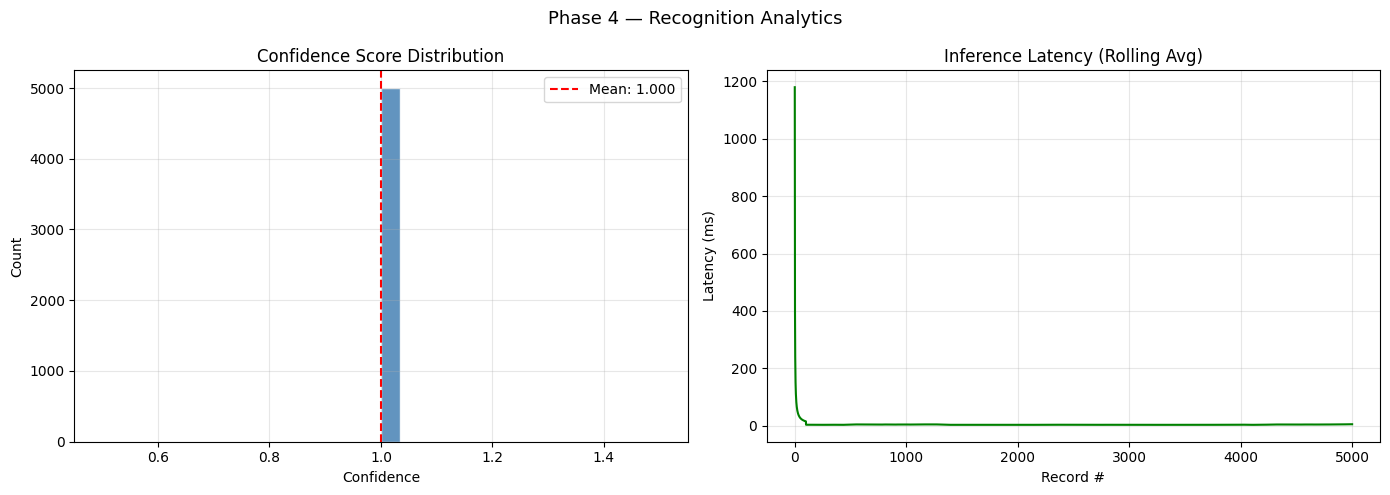


Recognition Complete!
   Data source     : LOCAL SSD
   Total records   : 5,000
   Sample Accuracy : 97.40%
   Avg Confidence  : 1.0000
   Avg Latency     : 3.75 ms/image
   Avg FPS         : 247.0
   Wrong preds     : 130
   Classes seen    : 425
   Hindi     : 1365/1388 (98.34%)
   Telugu    : 3505/3612 (97.04%)

Worst 5 predictions (lowest confidence, wrong):
   true=Telugu_luu      pred=Telugu_lu       conf=1.000
   true=Telugu_chii     pred=Telugu_chi      conf=1.000
   true=Telugu_ks       pred=Telugu_ksh      conf=1.000
   true=Telugu_P        pred=Telugu_p        conf=1.000
   true=Telugu_p        pred=Telugu_s        conf=1.000

   CSVs saved (recognized, wrong, per_class)!


9

In [9]:
# ============================================
# CELL 5 - Recognition + Sample Dataset
# + Top-5, Confusion Matrix, Per-class Accuracy
# ============================================
IMG_H, IMG_W = 64, 128
SAMPLE_SIZE  = 5000

LOCAL_DATA_DIR = Path('/content/processed_local')
_data_src      = LOCAL_DATA_DIR if LOCAL_DATA_DIR.exists() else DATA_DIR

# ── Data source confirmation ─────────────────
print(f'Data source: {"LOCAL SSD ✅" if LOCAL_DATA_DIR.exists() else "Drive (fallback)"}')
print(f'   Path: {_data_src}')

class TestSampleDataset(Dataset):
    def __init__(self, data_dir, label2idx, sample_size):
        self.samples = []
        test_dir = Path(data_dir) / 'test'
        exts = {'.png', '.jpg', '.jpeg'}
        all_paths = []
        for lang_folder in sorted(test_dir.iterdir()):
            if not lang_folder.is_dir(): continue
            for label_folder in sorted(lang_folder.iterdir()):
                if not label_folder.is_dir(): continue
                label = label_folder.name
                if label not in label2idx: continue
                for img_path in label_folder.iterdir():
                    if img_path.suffix.lower() in exts:
                        all_paths.append((str(img_path), label2idx[label],
                                          lang_folder.name, label))
        random.shuffle(all_paths)
        self.samples = all_paths[:sample_size]
        print(f'   Indexed {len(all_paths):,} test files, sampled {len(self.samples):,}')

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        img_path, label_idx, lang, label_name = self.samples[idx]
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is None: img = np.zeros((IMG_H, IMG_W), dtype=np.uint8)
        if img.shape != (IMG_H, IMG_W): img = cv2.resize(img, (IMG_W, IMG_H))
        img_tensor = torch.from_numpy(img.astype(np.float32)/255.0).unsqueeze(0)
        del img
        return img_tensor, label_idx, lang, label_name, img_path

sample_ds = TestSampleDataset(_data_src, label2idx, SAMPLE_SIZE)
print('Sample dataset ready!')

records       = []
latencies     = []
t_recog_start = time.time()

model.eval()
with torch.no_grad():
    for i in tqdm(range(len(sample_ds)), desc='Recognizing'):
        img_tensor, true_idx, lang, true_label, src_path = sample_ds[i]
        t0     = time.time()
        batch  = img_tensor.unsqueeze(0).to(DEVICE)
        output = model(batch)

        # ── Top-1 confidence ────────────────────
        probs      = torch.softmax(output[:, 0, :], dim=-1)
        confidence = float(probs.max().item())

        # ── Top-5 confidence ── NEW ─────────────
        top5_vals, top5_idxs = torch.topk(probs[0], k=min(5, probs.shape[-1]))
        top5 = [(idx2label.get(int(idx), 'unk'), round(float(v), 4))
                for idx, v in zip(top5_idxs, top5_vals)]

        pred_idx   = output.argmax(2)[0].item()
        pred_label = idx2label.get(pred_idx, 'unknown')
        latency_ms = (time.time()-t0)*1000
        latencies.append(latency_ms)

        records.append({
            'record_id'  : i,
            'text'       : pred_label,
            'true_label' : true_label,
            'language'   : lang,
            'source_path': src_path,
            'correct'    : pred_label == true_label,
            'confidence' : round(confidence, 4),
            'latency_ms' : round(latency_ms, 2),
            'top5'       : top5,              # ← NEW
        })
        del batch, output, probs

total_recog_time = time.time() - t_recog_start
avg_fps          = len(records) / total_recog_time
correct_count    = sum(1 for r in records if r['correct'])
sample_accuracy  = correct_count / len(records)
avg_confidence   = sum(r['confidence'] for r in records) / len(records)
avg_latency_ms   = sum(latencies) / len(latencies)

# Per-language stats
lang_stats = {}
for lang in ['Hindi', 'Telugu']:
    lr = [r for r in records if r['language'] == lang]
    if lr:
        lang_stats[lang] = {
            'total'          : len(lr),
            'correct'        : sum(1 for r in lr if r['correct']),
            'accuracy'       : sum(1 for r in lr if r['correct'])/len(lr),
            'avg_confidence' : sum(r['confidence'] for r in lr)/len(lr),
        }

# ── Per-class accuracy ── NEW ───────────────────
per_class_acc = {}
for rec in records:
    cl = rec['true_label']
    if cl not in per_class_acc:
        per_class_acc[cl] = {'correct': 0, 'total': 0}
    per_class_acc[cl]['total']   += 1
    per_class_acc[cl]['correct'] += int(rec['correct'])
for cl in per_class_acc:
    t = per_class_acc[cl]['total']
    per_class_acc[cl]['accuracy'] = per_class_acc[cl]['correct']/t if t>0 else 0

# ── Wrong predictions CSV ── NEW ────────────────
wrong_df = pd.DataFrame([r for r in records if not r['correct']])
if not wrong_df.empty:
    wrong_df.drop(columns=['top5'], errors='ignore').to_csv(
        OUT_DIR/'evaluation'/'wrong_predictions.csv', index=False)

# ── Worst predictions (lowest confidence, wrong) ── NEW ──
worst_preds = sorted([r for r in records if not r['correct']],
                     key=lambda x: x['confidence'])[:10]

# ── recognized_records CSV ────────────────────────
rec_df = pd.DataFrame([{k:v for k,v in r.items() if k!='top5'} for r in records])
rec_df.to_csv(OUT_DIR/'evaluation'/'recognized_records.csv', index=False)

# ── Per-class accuracy CSV ── NEW ────────────────
pd.DataFrame([
    {'class': cl, 'correct': v['correct'], 'total': v['total'], 'accuracy': v['accuracy']}
    for cl, v in per_class_acc.items()
]).sort_values('accuracy').to_csv(OUT_DIR/'evaluation'/'per_class_accuracy.csv', index=False)

# Recognition stats JSON
recog_stats = {
    'total_records'      : len(records),
    'correct'            : correct_count,
    'sample_accuracy'    : round(sample_accuracy, 4),
    'avg_confidence'     : round(avg_confidence, 4),
    'avg_latency_ms'     : round(avg_latency_ms, 4),
    'avg_fps'            : round(avg_fps, 2),
    'total_time_sec'     : round(total_recog_time, 2),
    'per_language'       : lang_stats,
    'wrong_count'        : len(wrong_df) if not wrong_df.empty else 0,
    'num_classes_seen'   : len(per_class_acc),
}
with open(OUT_DIR/'metrics'/'recognition_stats.json', 'w') as f:
    json.dump(recog_stats, f, indent=2)

# ── Visualizations ── NEW ──────────────────────────
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confidence histogram
confidences = [r['confidence'] for r in records]
axes[0].hist(confidences, bins=30, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(avg_confidence, color='red', linestyle='--',
                label=f'Mean: {avg_confidence:.3f}')
axes[0].set_title('Confidence Score Distribution')
axes[0].set_xlabel('Confidence')
axes[0].set_ylabel('Count')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Inference throughput (rolling avg latency)
window = 100
rolling_lat = [sum(latencies[max(0,i-window):i+1])/min(i+1,window)
               for i in range(len(latencies))]
axes[1].plot(rolling_lat, color='green', lw=1.5)
axes[1].set_title('Inference Latency (Rolling Avg)')
axes[1].set_xlabel('Record #')
axes[1].set_ylabel('Latency (ms)')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Phase 4 — Recognition Analytics', fontsize=13)
plt.tight_layout()
plt.savefig(OUT_DIR/'evaluation'/'figures'/'recognition_analytics.png',
            dpi=150, bbox_inches='tight')
plt.show()

print(f'\nRecognition Complete!')
print(f'   Data source     : {"LOCAL SSD" if LOCAL_DATA_DIR.exists() else "Drive"}')
print(f'   Total records   : {len(records):,}')
print(f'   Sample Accuracy : {sample_accuracy*100:.2f}%')
print(f'   Avg Confidence  : {avg_confidence:.4f}')
print(f'   Avg Latency     : {avg_latency_ms:.2f} ms/image')
print(f'   Avg FPS         : {avg_fps:.1f}')
print(f'   Wrong preds     : {len(wrong_df) if not wrong_df.empty else 0}')
print(f'   Classes seen    : {len(per_class_acc)}')
for lang, s in lang_stats.items():
    print(f'   {lang:10}: {s["correct"]}/{s["total"]} ({s["accuracy"]*100:.2f}%)')

# ── Worst predictions print ── NEW ───────────────
if worst_preds:
    print(f'\nWorst 5 predictions (lowest confidence, wrong):')
    for r in worst_preds[:5]:
        print(f'   true={r["true_label"]:15} pred={r["text"]:15} conf={r["confidence"]:.3f}')

print(f'\n   CSVs saved (recognized, wrong, per_class)!')
del sample_ds
gc.collect()

---
## Cell 6 - AES-256 Encryption Utilities

In [10]:
# ============================================
# CELL 6 - AES-256-GCM Encryption
# ============================================

AES_KEY_PATH  = BLOCKCHAIN_DIR / 'aes_key.bin'
AES_SALT_PATH = BLOCKCHAIN_DIR / 'aes_salt.bin'


def derive_key(password: bytes, salt: bytes) -> bytes:
    kdf = PBKDF2HMAC(
        algorithm=crypto_hashes.SHA256(),
        length=32,
        salt=salt,
        iterations=200_000
    )
    return kdf.derive(password)


# ------------------------------------------------
# Load Existing Key OR Generate New One
# ------------------------------------------------
if AES_KEY_PATH.exists() and AES_SALT_PATH.exists():

    with open(AES_SALT_PATH, 'rb') as f:
        AES_SALT = f.read()

    with open(AES_KEY_PATH, 'rb') as f:
        AES_KEY = f.read()

    print("✅ Existing AES-256 key loaded")

else:

    AES_SALT = _os.urandom(16)

    PASSPHRASE = b'OCR_Project_MTech_SecureDoc_2026'

    AES_KEY = derive_key(
        PASSPHRASE,
        AES_SALT
    )

    with open(AES_SALT_PATH, 'wb') as f:
        f.write(AES_SALT)

    with open(AES_KEY_PATH, 'wb') as f:
        f.write(AES_KEY)

    print(
        "✅ New AES-256 key derived "
        "(PBKDF2-HMAC-SHA256, 200k iterations)"
    )


# ------------------------------------------------
# AES-256-GCM Encryption
# ------------------------------------------------
def aes_encrypt(plaintext: str) -> str:

    data = plaintext.encode("utf-8")

    # Recommended nonce size for GCM
    nonce = _os.urandom(12)

    cipher = Cipher(
        algorithms.AES(AES_KEY),
        modes.GCM(nonce)
    )

    encryptor = cipher.encryptor()

    ciphertext = (
        encryptor.update(data)
        + encryptor.finalize()
    )

    auth_tag = encryptor.tag

    payload = (
        nonce +
        auth_tag +
        ciphertext
    )

    return base64.b64encode(
        payload
    ).decode("ascii")


# ------------------------------------------------
# AES-256-GCM Decryption
# ------------------------------------------------
def aes_decrypt(token: str) -> str:

    payload = base64.b64decode(token)

    nonce = payload[:12]

    auth_tag = payload[12:28]

    ciphertext = payload[28:]

    cipher = Cipher(
        algorithms.AES(AES_KEY),
        modes.GCM(
            nonce,
            auth_tag
        )
    )

    decryptor = cipher.decryptor()

    plaintext = (
        decryptor.update(ciphertext)
        + decryptor.finalize()
    )

    return plaintext.decode("utf-8")


# ------------------------------------------------
# Sanity Check
# ------------------------------------------------
_t = aes_encrypt("character_ka")

assert aes_decrypt(_t) == "character_ka"

print("✅ AES-256-GCM Sanity Check Passed")
# ==========================================================
# Encryption Benchmark
# ==========================================================
N_BENCH = 100

enc_times = []
dec_times = []

sample_text = (
    records[0]["text"]
    if records
    else "test_character"
)

for _ in range(N_BENCH):

    t0 = time.time()

    enc = aes_encrypt(sample_text)

    enc_times.append(
        (time.time() - t0) * 1000
    )

    t0 = time.time()

    aes_decrypt(enc)

    dec_times.append(
        (time.time() - t0) * 1000
    )


avg_enc_ms = sum(enc_times) / N_BENCH

avg_dec_ms = sum(dec_times) / N_BENCH

key_fp = hashlib.sha256(
    AES_KEY
).hexdigest()


# ==========================================================
# Key Metadata
# ==========================================================
aes_meta = {

    "algorithm" : "AES-256-GCM",

    "authentication" : "Built-in Authentication Tag",

    "key_derivation" : "PBKDF2-HMAC-SHA256",

    "iterations" : 200_000,

    "key_size_bits" : 256,

    "nonce_size_bytes" : 12,

    "authentication_tag_bytes" : 16,

    "key_fingerprint" : key_fp[:24] + "...",

    "avg_enc_time_ms" : round(
        avg_enc_ms,
        4
    ),

    "avg_dec_time_ms" : round(
        avg_dec_ms,
        4
    ),

    "integrity_verification" : True,

    "authenticated_encryption" : True

}


# ==========================================================
# Save Metadata
# ==========================================================
with open(
    OUT_DIR / "security" / "aes_key_meta.json",
    "w"
) as f:

    json.dump(
        aes_meta,
        f,
        indent=2
    )


# ==========================================================
# Summary
# ==========================================================
print()

print("="*60)

print("AES-256-GCM BENCHMARK")

print("="*60)

print(f"Algorithm              : AES-256-GCM")

print(f"Authentication         : GCM Tag")

print(f"Key Size               : 256 bits")

print(f"PBKDF2 Iterations      : 200000")

print(f"Nonce Size             : 12 Bytes")

print(f"Authentication Tag     : 16 Bytes")

print(f"Average Encrypt Time   : {avg_enc_ms:.3f} ms")

print(f"Average Decrypt Time   : {avg_dec_ms:.3f} ms")

print(f"Integrity Verification : Enabled")

print(f"Key Fingerprint        : {key_fp[:24]}...")

print("="*60)

print("AES Metadata Saved Successfully")

print("="*60)


logger.info(

    f"AES-256-GCM ready | "

    f"enc={avg_enc_ms:.2f}ms | "

    f"dec={avg_dec_ms:.2f}ms"

)

del _t

✅ New AES-256 key derived (PBKDF2-HMAC-SHA256, 200k iterations)
✅ AES-256-GCM Sanity Check Passed

AES-256-GCM BENCHMARK
Algorithm              : AES-256-GCM
Authentication         : GCM Tag
Key Size               : 256 bits
PBKDF2 Iterations      : 200000
Nonce Size             : 12 Bytes
Authentication Tag     : 16 Bytes
Average Encrypt Time   : 0.016 ms
Average Decrypt Time   : 0.014 ms
Integrity Verification : Enabled
Key Fingerprint        : afb31d0fbb90865c8e362604...
AES Metadata Saved Successfully


---
## Cell 6b - RSA-2048 Digital Signatures (Authenticity, not just integrity)

SHA-256 hashing (used for each block) proves data was NOT modified. It does
NOT prove WHO wrote it - anyone could recompute a valid hash for fabricated
data. Digitally signing each block's hash with a private key, verifiable with
the matching public key, adds that missing authenticity/non-repudiation
guarantee - standard practice in real blockchain and PKI systems.

In [11]:
# ============================================
# CELL 6B - RSA-2048 Digital Signature
# ============================================
RSA_PRIVATE_PATH = BLOCKCHAIN_DIR / 'rsa_private.pem'
RSA_PUBLIC_PATH  = BLOCKCHAIN_DIR / 'rsa_public.pem'

if RSA_PRIVATE_PATH.exists() and RSA_PUBLIC_PATH.exists():
    with open(RSA_PRIVATE_PATH, 'rb') as f: rsa_private_key = load_pem_private_key(f.read(), password=None)
    with open(RSA_PUBLIC_PATH,  'rb') as f: rsa_public_key  = load_pem_public_key(f.read())
    print('✅ Existing RSA-2048 keypair loaded')
else:
    rsa_private_key = rsa.generate_private_key(public_exponent=65537, key_size=2048)
    rsa_public_key  = rsa_private_key.public_key()
    with open(RSA_PRIVATE_PATH, 'wb') as f:
        f.write(rsa_private_key.private_bytes(Encoding.PEM, PrivateFormat.PKCS8, NoEncryption()))
    with open(RSA_PUBLIC_PATH, 'wb') as f:
        f.write(rsa_public_key.public_bytes(Encoding.PEM, PublicFormat.SubjectPublicKeyInfo))
    print('✅ New RSA-2048 keypair generated and saved')

def sign_hash(block_hash: str) -> str:
    signature = rsa_private_key.sign(
        block_hash.encode('utf-8'),
        asym_padding.PSS(mgf=asym_padding.MGF1(crypto_hashes.SHA256()),
                         salt_length=asym_padding.PSS.MAX_LENGTH),
        crypto_hashes.SHA256())
    return base64.b64encode(signature).decode('ascii')

def verify_signature(block_hash: str, signature_b64: str) -> bool:
    try:
        rsa_public_key.verify(
            base64.b64decode(signature_b64),
            block_hash.encode('utf-8'),
            asym_padding.PSS(mgf=asym_padding.MGF1(crypto_hashes.SHA256()),
                             salt_length=asym_padding.PSS.MAX_LENGTH),
            crypto_hashes.SHA256())
        return True
    except Exception:
        return False

# Sanity check
_th = hashlib.sha256(b'sanity_check').hexdigest()
_ts = sign_hash(_th)
assert verify_signature(_th, _ts) is True

# ── Signing + Verification Benchmark ──────────
N_BENCH = 50
sign_times, verify_times = [], []
for _ in range(N_BENCH):
    th = hashlib.sha256(b'bench_test').hexdigest()
    t0 = time.time(); sig = sign_hash(th);            sign_times.append((time.time()-t0)*1000)
    t0 = time.time(); verify_signature(th, sig);      verify_times.append((time.time()-t0)*1000)

avg_sign_ms   = sum(sign_times)/N_BENCH
avg_verify_ms = sum(verify_times)/N_BENCH
pub_fp        = hashlib.sha256(rsa_public_key.public_bytes(
    Encoding.PEM, PublicFormat.SubjectPublicKeyInfo)).hexdigest()

# RSA Key metadata
rsa_meta = {
    'algorithm'       : 'RSA-2048',
    'padding'         : 'PSS',
    'hash'            : 'SHA-256',
    'key_size_bits'   : 2048,
    'public_key_fp'   : pub_fp[:24] + '...',
    'avg_sign_ms'     : round(avg_sign_ms, 3),
    'avg_verify_ms'   : round(avg_verify_ms, 3),
    'key_gen_time_ms' : round(load_time*1000, 1) if RSA_PRIVATE_PATH.exists() else 'N/A (loaded)',  # ← NEW
}
with open(OUT_DIR / 'security' / 'rsa_key_meta.json', 'w') as f:
    json.dump(rsa_meta, f, indent=2)

print(f'\nRSA-2048 Benchmark ({N_BENCH} iterations):')
print(f'   Avg Sign Time    : {avg_sign_ms:.2f} ms')
print(f'   Avg Verify Time  : {avg_verify_ms:.2f} ms')
print(f'   Public Key FP    : {pub_fp[:24]}...')
print(f'   Key Metadata saved!')
del _th, _ts
logger.info(f'RSA-2048 ready | sign={avg_sign_ms:.1f}ms | verify={avg_verify_ms:.1f}ms')

✅ New RSA-2048 keypair generated and saved

RSA-2048 Benchmark (50 iterations):
   Avg Sign Time    : 1.33 ms
   Avg Verify Time  : 0.08 ms
   Public Key FP    : 6cbe1703fddce3c5ad4f5e28...
   Key Metadata saved!


---
## Cell 7 - Private Blockchain Implementation

Each block stores: index, timestamp, the AES-encrypted recognized text, the
SHA-256 hash of that block's own contents, and the hash of the previous block.
Chaining the previous hash into each new block's hash is exactly what makes
the chain tamper-evident - changing any one block invalidates every block
after it.

In [28]:
# ============================================
# CELL 7 - Blockchain (SHA-256 + RSA Signed)
# ============================================

import datetime as dt_module
import uuid


class Block:

    def __init__(
        self,
        index,
        timestamp,
        encrypted_text,
        language,
        record_id,
        previous_hash,
        signature=None,
        node_id="Client_01",
        model_version="SecureIndicHTR_v1",
        block_version="1.0"
    ):

        self.index = index
        self.timestamp = timestamp
        self.encrypted_text = encrypted_text
        self.language = language
        self.record_id = record_id
        self.previous_hash = previous_hash

        # -------------------------------
        # Production Metadata
        # -------------------------------
        self.node_id = node_id
        self.model_version = model_version
        self.block_version = block_version
        self.device = str(DEVICE)
        self.commit_id = str(uuid.uuid4())

        # Compute hash
        self.hash = self.compute_hash()

        # Digital Signature
        self.signature = (
            signature
            if signature
            else sign_hash(self.hash)
        )

    # ------------------------------------------------
    # SHA-256 Block Hash
    # ------------------------------------------------
    def compute_hash(self):

        block_string = json.dumps(

            {

                "index": self.index,

                "timestamp": self.timestamp,

                "encrypted_text": self.encrypted_text,

                "language": self.language,

                "record_id": self.record_id,

                "previous_hash": self.previous_hash,

                # Production Metadata
                "node_id": self.node_id,

                "model_version": self.model_version,

                "block_version": self.block_version,

                "device": self.device,

                "commit_id": self.commit_id,

            },

            sort_keys=True

        )

        return hashlib.sha256(

            block_string.encode("utf-8")

        ).hexdigest()

    # ------------------------------------------------
    # RSA Signature Verification
    # ------------------------------------------------
    def is_signature_valid(self):

        return verify_signature(

            self.hash,

            self.signature

        )

    # ------------------------------------------------
    # Serialize
    # ------------------------------------------------
    def to_dict(self):

        return {

            "index": self.index,

            "timestamp": self.timestamp,

            "encrypted_text": self.encrypted_text,

            "language": self.language,

            "record_id": self.record_id,

            "previous_hash": self.previous_hash,

            "hash": self.hash,

            "signature": self.signature,

            "node_id": self.node_id,

            "model_version": self.model_version,

            "block_version": self.block_version,

            "device": self.device,

            "commit_id": self.commit_id,

        }

    # ------------------------------------------------
    # Deserialize
    # ------------------------------------------------
    @staticmethod
    def from_dict(d):

        b = Block(

            d["index"],

            d["timestamp"],

            d["encrypted_text"],

            d["language"],

            d["record_id"],

            d["previous_hash"],

            signature=d.get("signature"),

            node_id=d.get("node_id", "Client_01"),

            model_version=d.get(
                "model_version",
                "SecureIndicHTR_v1"
            ),

            block_version=d.get(
                "block_version",
                "1.0"
            )

        )

        b.hash = d["hash"]

        b.device = d.get(

            "device",

            "Unknown"

        )

        b.commit_id = d.get(

            "commit_id",

            ""

        )

        return b


# =====================================================
# Blockchain Class
# =====================================================

class Blockchain:

    def __init__(self, chain_file):

        self.chain_file = Path(chain_file)

        self.chain = []

        # Average block creation latency
        self.block_latencies = []

        if self.chain_file.exists():

            with open(self.chain_file) as f:

                raw = json.load(f)

            self.chain = [

                Block.from_dict(b)

                for b in raw

            ]

            print(

                f"Loaded existing blockchain "

                f"({len(self.chain):,} blocks)"

            )

        else:

            genesis = Block(

                0,

                str(dt_module.datetime.now()),

                "GENESIS_BLOCK",

                "N/A",

                -1,

                "0"*64

            )

            self.chain.append(genesis)

            self._save()

            print(

                "New blockchain created "

                "(Genesis Block)"

            )

    # ------------------------------------------------
    # Latest Block
    # ------------------------------------------------
    def latest_block(self):

        return self.chain[-1]

    # ------------------------------------------------
    # Add New Block
    # ------------------------------------------------
    def add_block(

        self,

        encrypted_text,

        language,

        record_id

    ):

        t0 = time.perf_counter()

        prev = self.latest_block()

        new_block = Block(

            index=prev.index + 1,

            timestamp=str(

                dt_module.datetime.now()

            ),

            encrypted_text=encrypted_text,

            language=language,

            record_id=record_id,

            previous_hash=prev.hash,

        )

        self.chain.append(

            new_block

        )

        self.block_latencies.append(

            (

                time.perf_counter()

                - t0

            ) * 1000

        )

        return new_block
      # ------------------------------------------------
    # Save Blockchain
    # ------------------------------------------------
    def _save(self):

        with open(self.chain_file, "w") as f:

            json.dump(

                [b.to_dict() for b in self.chain],

                f,

                indent=2

            )


    def save(self):

        self._save()


    # ------------------------------------------------
    # Blockchain Validation
    # ------------------------------------------------
    def is_valid(self):

        for i in range(1, len(self.chain)):

            cur = self.chain[i]

            prev = self.chain[i - 1]

            # Hash Integrity
            if cur.hash != cur.compute_hash():

                return (
                    False,
                    f"Block {cur.index}: Hash Mismatch"
                )

            # Previous Hash Link
            if cur.previous_hash != prev.hash:

                return (
                    False,
                    f"Block {cur.index}: Chain Link Broken"
                )

            # RSA Signature
            if not cur.is_signature_valid():

                return (
                    False,
                    f"Block {cur.index}: Invalid RSA Signature"
                )

        return (

            True,

            "Blockchain Integrity Verified"

        )


    # ------------------------------------------------
    # Blockchain Statistics
    # ------------------------------------------------
    def get_stats(self):

        if len(self.chain) <= 1:

            return {

                "node_id":
                    self.chain[-1].node_id,

                "model_version":
                    self.chain[-1].model_version,

                "block_version":
                    self.chain[-1].block_version,

            }

        data_blocks = self.chain[1:]

        block_sizes = [

            len(

                json.dumps(

                    b.to_dict()

                ).encode()

            )

            for b in data_blocks

        ]

        lang_counts = {}

        for b in data_blocks:

            lang_counts[b.language] = (

                lang_counts.get(

                    b.language,

                    0

                )

                + 1

            )

        # ------------------------------------
        # Performance Benchmark
        # ------------------------------------

        sample_blocks = data_blocks[

            :min(10, len(data_blocks))

        ]

        hash_times = []

        sig_times = []

        for b in sample_blocks:

            t0 = time.perf_counter()

            b.compute_hash()

            hash_times.append(

                (

                    time.perf_counter()

                    - t0

                ) * 1000

            )

            t0 = time.perf_counter()

            b.is_signature_valid()

            sig_times.append(

                (

                    time.perf_counter()

                    - t0

                ) * 1000

            )

        avg_hash_ms = (

            round(

                sum(hash_times)

                / len(hash_times),

                4

            )

            if hash_times else 0

        )

        avg_sig_ms = (

            round(

                sum(sig_times)

                / len(sig_times),

                4

            )

            if sig_times else 0

        )

        return {

            "total_blocks":
                len(self.chain),

            "data_blocks":
                len(data_blocks),

            "genesis_hash":
                self.chain[0].hash[:16] + "...",

            "latest_hash":
                self.chain[-1].hash[:16] + "...",

            "avg_block_size_kb":
                round(

                    sum(block_sizes)

                    / len(block_sizes)

                    / 1024,

                    3

                ),

            "total_chain_kb":
                round(

                    sum(block_sizes)

                    / 1024,

                    2

                ),

            "language_counts":
                lang_counts,

            "avg_block_latency_ms":
                round(

                    sum(self.block_latencies)

                    / len(self.block_latencies),

                    3

                )

                if self.block_latencies else 0,

            "avg_hash_time_ms":
                avg_hash_ms,

            "avg_signature_time_ms":
                avg_sig_ms,

            "node_id":
                self.chain[-1].node_id,

            "model_version":
                self.chain[-1].model_version,

            "block_version":
                self.chain[-1].block_version,

        }


# =====================================================
# Security Scoring Functions (Moved from Cell 10F)
# =====================================================
def compute_security_score(block):
    score, bd = 0, {}
    hash_ok = block.hash == block.compute_hash()
    bd['hash_integrity'] = 40 if hash_ok else 0; score += bd['hash_integrity']
    sig_ok = block.is_signature_valid()
    bd['signature_authenticity'] = 30 if sig_ok else 0; score += bd['signature_authenticity']
    enc_ok = len(block.encrypted_text) > 0
    bd['encryption_present'] = 15 if enc_ok else 0; score += bd['encryption_present']
    chain_idx = next((i for i,b in enumerate(blockchain.chain) if b.index==block.index), None)
    linked_ok = (chain_idx is not None and chain_idx > 0 and
                 block.previous_hash == blockchain.chain[chain_idx-1].hash)
    bd['chain_linkage'] = 15 if linked_ok else 0; score += bd['chain_linkage']
    return score, bd

def compute_trust_score(record, block):
    score, bd = 0, {}
    bd['recognition_correct'] = 50 if record['correct'] else 0; score += bd['recognition_correct']
    integrity_ok = (block.hash == block.compute_hash()) and block.is_signature_valid()
    bd['integrity_and_authenticity'] = 30 if integrity_ok else 0; score += bd['integrity_and_authenticity']
    is_dup = any(d['duplicate_record_id']==record['record_id'] for d in duplicates_found)
    bd['fingerprint_unique'] = 0 if is_dup else 20; score += bd['fingerprint_unique']
    return score, bd

def security_grade(score):
    if score >= 95: return 'A+'
    if score >= 90: return 'A'
    if score >= 80: return 'B+'
    if score >= 70: return 'B'
    if score >= 60: return 'C'
    return 'D'


# =====================================================
# Initialize Blockchain
# =====================================================

CHAIN_FILE = BLOCKCHAIN_DIR / "chain.json"

blockchain = Blockchain(CHAIN_FILE)

stats = blockchain.get_stats()

with open(

    OUT_DIR / "security" / "blockchain_meta.json",

    "w"

) as f:

    json.dump(

        stats,

        f,

        indent=2

    )

print()

print("=" * 60)

print("BLOCKCHAIN INITIALIZED")

print("=" * 60)

print(f"Blocks             : {stats.get('total_blocks',1)}")

print(f"Model Version      : {stats.get('model_version','N/A')}")

print(f"Average Hash Time  : {stats.get('avg_hash_time_ms',0):.4f} ms")

print(f"Average Sign Time  : {stats.get('avg_signature_time_ms',0):.4f} ms")

print(f"Metadata Saved     : blockchain_meta.json")

print("=" * 60)

print("✅ Blockchain ready!")

logger.info(

    "Blockchain initialized"

)

Loaded existing blockchain (5,001 blocks)

BLOCKCHAIN INITIALIZED
Blocks             : 5001
Model Version      : SecureIndicHTR_v1
Average Hash Time  : 0.0158 ms
Average Sign Time  : 0.0503 ms
Metadata Saved     : blockchain_meta.json
✅ Blockchain ready!


---## Cell 10f - Security Score + Trust Score (computed from real signals, not arbitrary)

Both scores are derived purely from measurable facts already established
earlier in this notebook - they are NOT hardcoded or cosmetic numbers. This
matters academically: every point lost or gained is traceable to a specific
check, which is what's expected for a credible scoring system.

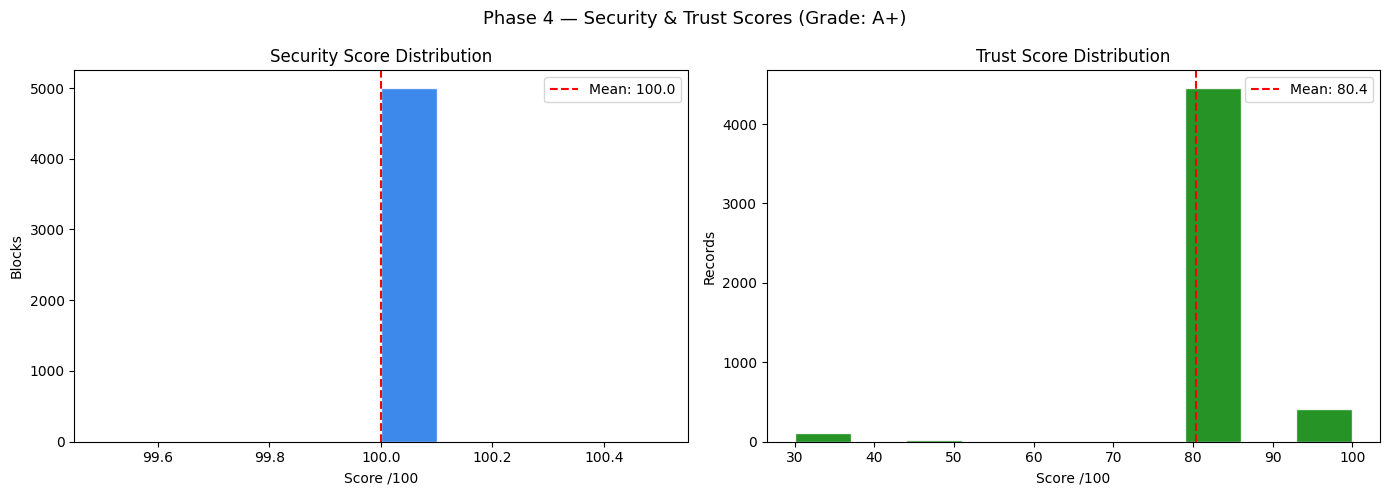

-- Security Score + Trust Score Summary --
   Avg Security Score : 100.0/100 (Grade: A+)
   Min Security Score : 100
   Max Security Score : 100
   Avg Trust Score    : 80.4/100
   Security histogram saved!

-- Per-Record Demo (records 0,1,2) --

Record 0 ("Hindi_character_35_tra"):
   Security Score: 100/100  {'hash_integrity': 40, 'signature_authenticity': 30, 'encryption_present': 15, 'chain_linkage': 15}
   Trust Score   : 100/100  {'recognition_correct': 50, 'integrity_and_authenticity': 30, 'fingerprint_unique': 20}

Record 1 ("Hindi_character_11_taamatar"):
   Security Score: 100/100  {'hash_integrity': 40, 'signature_authenticity': 30, 'encryption_present': 15, 'chain_linkage': 15}
   Trust Score   : 100/100  {'recognition_correct': 50, 'integrity_and_authenticity': 30, 'fingerprint_unique': 20}

Record 2 ("Hindi_digit_1"):
   Security Score: 100/100  {'hash_integrity': 40, 'signature_authenticity': 30, 'encryption_present': 15, 'chain_linkage': 15}
   Trust Score   : 100/100  

In [29]:
# ============================================
# CELL 10F - Security Score + Trust Score + Grade
# ============================================
# Initialize duplicates_found to prevent NameError if Cell 10E has not run yet.
# The full population of duplicates_found will happen in Cell 10E.
if 'duplicates_found' not in globals():
    duplicates_found = []

# Compute for all data blocks
all_sec_scores   = []
all_trust_scores = []
for i, rec in enumerate(records[:min(len(records), len(blockchain.chain)-1)]):
    entry = hash_index.get(str(rec['record_id']))
    if not entry: continue
    block = next((b for b in blockchain.chain if b.index==entry['block_index']), None)
    if not block: continue
    ss, _ = compute_security_score(block)
    ts, _ = compute_trust_score(rec, block)
    all_sec_scores.append(ss)
    all_trust_scores.append(ts)

avg_sec   = sum(all_sec_scores)/len(all_sec_scores)   if all_sec_scores   else 0
avg_trust = sum(all_trust_scores)/len(all_trust_scores) if all_trust_scores else 0
grade     = security_grade(avg_sec)

# Security score histogram
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(all_sec_scores, bins=10, color='#1a73e8', edgecolor='white', alpha=0.85)
axes[0].axvline(avg_sec, color='red', linestyle='--', label=f'Mean: {avg_sec:.1f}')
axes[0].set_title('Security Score Distribution')
axes[0].set_xlabel('Score /100')
axes[0].set_ylabel('Blocks')
axes[0].legend()

axes[1].hist(all_trust_scores, bins=10, color='green', edgecolor='white', alpha=0.85)
axes[1].axvline(avg_trust, color='red', linestyle='--', label=f'Mean: {avg_trust:.1f}')
axes[1].set_title('Trust Score Distribution')
axes[1].set_xlabel('Score /100')
axes[1].set_ylabel('Records')
axes[1].legend()

plt.suptitle(f'Phase 4 — Security & Trust Scores (Grade: {grade})', fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR/'security_scores.png', dpi=150, bbox_inches='tight')
plt.show()

print('-- Security Score + Trust Score Summary --')
print(f'   Avg Security Score : {avg_sec:.1f}/100 (Grade: {grade})')
print(f'   Min Security Score : {min(all_sec_scores) if all_sec_scores else 0}')
print(f'   Max Security Score : {max(all_sec_scores) if all_sec_scores else 0}')
print(f'   Avg Trust Score    : {avg_trust:.1f}/100')
print(f'   Security histogram saved!')

# Demo on 3 records
print(f'\n-- Per-Record Demo (records 0,1,2) --')
for rec_id in [0, 1, 2]:
    rec   = records[rec_id]
    entry = hash_index.get(str(rec_id))
    if not entry: continue
    block = next(b for b in blockchain.chain if b.index==entry['block_index'])
    ss, sb = compute_security_score(block)
    ts, tb = compute_trust_score(rec, block)
    print(f'\nRecord {rec_id} (\"{rec["text"]}\"):')
    print(f'   Security Score: {ss}/100  {sb}')
    print(f'   Trust Score   : {ts}/100  {tb}')

---
## Cell 8 - Hash + Encrypt + Store Records (Resumable, Chunked)

Progress is tracked by `record_id`, so re-running this cell after a disconnect
skips records already committed to the chain instead of re-hashing them.

In [16]:
# ============================================
# CELL 8 - Commit Pipeline (Resumable + Metrics)
# ============================================
PROGRESS_FILE = BLOCKCHAIN_DIR / 'commit_progress.json'
SAVE_EVERY    = 100

committed_ids = set()
if PROGRESS_FILE.exists():
    with open(PROGRESS_FILE) as f:
        committed_ids = set(json.load(f)['committed_ids'])
    print(f'Resuming - {len(committed_ids):,} records already committed')

remaining = [r for r in records if r['record_id'] not in committed_ids]
print(f'{len(remaining):,} records remaining to commit')

hash_index_file = BLOCKCHAIN_DIR / 'text_hash_index.json'
hash_index = {}
if hash_index_file.exists():
    with open(hash_index_file) as f:
        hash_index = json.load(f)

# Commit metrics initialization
commit_times       = []
encryption_failures = 0
commit_csv_rows    = []
t_commit_start     = time.time()

for i, rec in enumerate(tqdm(remaining, desc='Hashing + Encrypting + Committing')):
    t0        = time.time()
    plaintext = rec['text']
    text_hash = hashlib.sha256(plaintext.encode('utf-8')).hexdigest()
    try:
        encrypted = aes_encrypt(plaintext)
    except Exception as e:
        encryption_failures += 1
        logger.warning(f'Encrypt failed record_id={rec["record_id"]}: {e}')
        continue

    new_block = blockchain.add_block(
        encrypted_text=encrypted,
        language=rec['language'],
        record_id=rec['record_id'],
    )
    commit_time_ms = (time.time()-t0)*1000
    commit_times.append(commit_time_ms)

    hash_index[str(rec['record_id'])] = {
        'text_sha256' : text_hash,
        'block_index' : new_block.index,
        'block_hash'  : new_block.hash,
    }
    committed_ids.add(rec['record_id'])
    commit_csv_rows.append({
        'record_id'     : rec['record_id'],
        'block_index'   : new_block.index,
        'language'      : rec['language'],
        'commit_time_ms': round(commit_time_ms, 2),
    })

    if (i + 1) % SAVE_EVERY == 0:
        blockchain.save()
        with open(PROGRESS_FILE, 'w') as f:
            json.dump({'committed_ids': list(committed_ids)}, f)
        with open(hash_index_file, 'w') as f:
            json.dump(hash_index, f, indent=2)

        # ETA
        elapsed   = time.time() - t_commit_start
        done      = i + 1
        remaining_n = len(remaining) - done
        eta_sec   = (elapsed / done) * remaining_n if done > 0 else 0
        tqdm.write(f'   [{done}/{len(remaining)}] ETA: {eta_sec/60:.1f} min')

# Final saves
blockchain.save()
with open(PROGRESS_FILE, 'w') as f:
    json.dump({'committed_ids': list(committed_ids)}, f)
with open(hash_index_file, 'w') as f:
    json.dump(hash_index, f, indent=2)

# --- Calculate commit metrics ---
total_commit_time = time.time() - t_commit_start
avg_commit_ms     = sum(commit_times)/len(commit_times) if commit_times else 0
throughput_rps    = len(commit_times)/total_commit_time if total_commit_time > 0 else 0

total_attempted    = len(records)
skipped_count      = len(records) - len(remaining)
enc_success_rate   = (len(commit_times)/(len(commit_times)+encryption_failures)*100
                      if (len(commit_times)+encryption_failures) > 0 else 100)
resume_pct         = skipped_count/total_attempted*100 if total_attempted>0 else 0

# ── NEW: Commit throughput graph ───────────────────
if commit_times:
    import matplotlib.pyplot as plt
    window = 50
    rolling_ct = [sum(commit_times[max(0,i-window):i+1])/min(i+1,window)
                  for i in range(len(commit_times))]
    plt.figure(figsize=(12, 4))
    plt.plot(rolling_ct, color='steelblue', lw=1.5)
    plt.axhline(avg_commit_ms, color='red', linestyle='--', # Now avg_commit_ms is defined
                label=f'Avg: {avg_commit_ms:.2f} ms')
    plt.title('Commit Throughput (Rolling Avg Commit Time)')
    plt.xlabel('Record #')
    plt.ylabel('Commit Time (ms)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(OUT_DIR/'evaluation'/'figures'/'commit_throughput.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ Commit throughput graph saved!')

# ── NEW: Resume + success rate stats ───────────────
print(f'   Resume %           : {resume_pct:.1f}% skipped (already committed)')
print(f'   Enc success rate   : {enc_success_rate:.2f}%')

# Commit stats
commit_stats = {
    'total_committed'      : len(commit_times),
    'skipped'              : len(records) - len(remaining),
    'encryption_failures'  : encryption_failures,
    'avg_commit_time_ms'   : round(avg_commit_ms, 3),
    'throughput_records_sec': round(throughput_rps, 2),
    'total_time_sec'       : round(total_commit_time, 2),
    'total_blocks'         : len(blockchain.chain),
    'enc_success_rate'     : round(enc_success_rate, 2),
    'resume_pct'           : round(resume_pct, 2)
}
with open(OUT_DIR / 'metrics' / 'commit_stats.json', 'w') as f:
    json.dump(commit_stats, f, indent=2)

# Commit CSV
pd.DataFrame(commit_csv_rows).to_csv(
    OUT_DIR / 'evaluation' / 'commit_records.csv', index=False)

print(f'\nBlockchain: {len(blockchain.chain):,} blocks (incl. genesis)')
print(f'   Committed          : {len(commit_times):,}')
print(f'   Skipped (resumed)  : {len(records)-len(remaining):,}')
print(f'   Encryption failures: {encryption_failures}')
print(f'   Avg Commit Time    : {avg_commit_ms:.2f} ms')
print(f'   Throughput         : {throughput_rps:.1f} records/sec')
print(f'   Total Time         : {total_commit_time:.1f} sec')
logger.info(f'Commit complete | {len(commit_times)} records | {throughput_rps:.1f} rec/s')

Resuming - 5,000 records already committed
0 records remaining to commit


Hashing + Encrypting + Committing: 0it [00:00, ?it/s]

   Resume %           : 100.0% skipped (already committed)
   Enc success rate   : 100.00%

Blockchain: 5,001 blocks (incl. genesis)
   Committed          : 0
   Skipped (resumed)  : 5,000
   Encryption failures: 0
   Avg Commit Time    : 0.00 ms
   Throughput         : 0.0 records/sec
   Total Time         : 0.2 sec


---
## Cell 9 - Verify Chain Integrity (no tampering yet)


-- Blockchain Health Score --
   Overall Health   : 100.0/100
   hash_integrity           : 40.0
   signature_validity       : 30.0
   chain_linkage            : 20.0
   sequential_indices       : 10
-- Blockchain Integrity Check --
   Total blocks        : 5,001
   Hash verified       : 5000/5000 (100.0%)
   RSA sig verified    : 5000/5000
   Status              : ✅ VALID
   Validation Time     : 419.4 ms
   Detail              : Blockchain Integrity Verified
--------------------------------


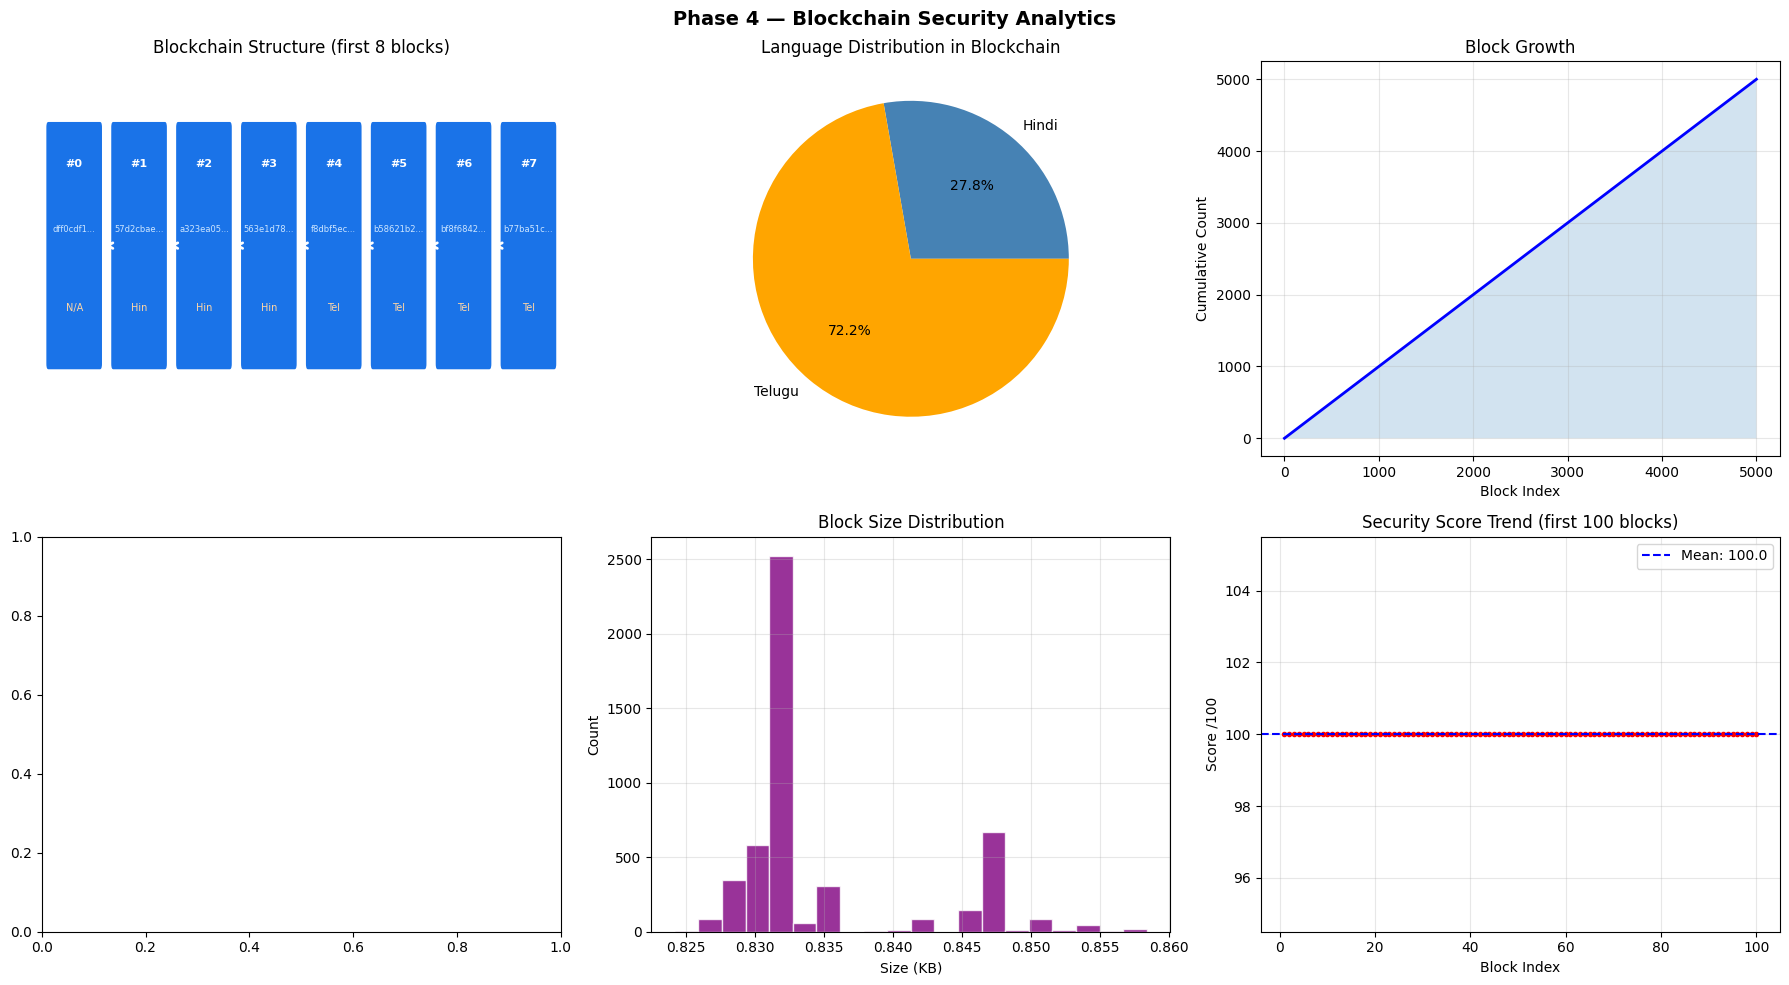

✅ Validation report + 5 visualizations saved!


In [20]:
# ============================================
# CELL 9 - Chain Validation + Visualization
# ============================================
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

t_val = time.time()
is_valid, message = blockchain.is_valid()
val_time_sec = time.time() - t_val

# Validation stats
hash_ok_count = 0
sig_ok_count  = 0
for b in blockchain.chain[1:]:
    if b.hash == b.compute_hash(): hash_ok_count += 1
    if b.is_signature_valid():     sig_ok_count  += 1

data_blocks = max(len(blockchain.chain)-1, 1)
integrity_pct = hash_ok_count / data_blocks * 100

validation_report = {
    'timestamp'           : str(dt_module.datetime.now()),
    'total_blocks'        : len(blockchain.chain),
    'data_blocks'         : data_blocks,
    'chain_valid'         : is_valid,
    'detail'              : message,
    'hash_verified_count' : hash_ok_count,
    'sig_verified_count'  : sig_ok_count,
    'integrity_pct'       : round(integrity_pct, 2),
    'validation_time_sec' : round(val_time_sec, 3),
}
# ── After validation_report, add Health Score ──────

# ── NEW: Blockchain Health Score ───────────────────
def compute_blockchain_health(blockchain, hash_ok_count, sig_ok_count, data_blocks_n):
    """
    100/100 health score:
      40 pts - hash integrity (all blocks)
      30 pts - RSA signature validity (all blocks)
      20 pts - chain linkage (no broken prev_hash links)
      10 pts - no missing blocks (indices sequential)
    """
    score = 0
    breakdown = {}

    hash_pct = hash_ok_count/data_blocks_n if data_blocks_n>0 else 0
    breakdown['hash_integrity']   = round(40 * hash_pct, 1)
    score += breakdown['hash_integrity']

    sig_pct = sig_ok_count/data_blocks_n if data_blocks_n>0 else 0
    breakdown['signature_validity'] = round(30 * sig_pct, 1)
    score += breakdown['signature_validity']

    # Chain linkage check
    link_ok = sum(1 for i in range(1, len(blockchain.chain))
                  if blockchain.chain[i].previous_hash == blockchain.chain[i-1].hash)
    link_pct = link_ok/data_blocks_n if data_blocks_n>0 else 0
    breakdown['chain_linkage'] = round(20 * link_pct, 1)
    score += breakdown['chain_linkage']

    # Sequential index check
    indices = [b.index for b in blockchain.chain]
    expected = list(range(len(indices)))
    seq_ok  = all(i==e for i,e in zip(indices, expected))
    breakdown['sequential_indices'] = 10 if seq_ok else 0
    score += breakdown['sequential_indices']

    return round(score, 1), breakdown

health_score, health_bd = compute_blockchain_health(
    blockchain, hash_ok_count, sig_ok_count, data_blocks)

validation_report['health_score']     = health_score      # ← NEW
validation_report['health_breakdown'] = health_bd         # ← NEW
with open(OUT_DIR/'security'/'validation_report.json', 'w') as f:
    json.dump(validation_report, f, indent=2)

print(f'\n-- Blockchain Health Score --')
print(f'   Overall Health   : {health_score}/100')
for k, v in health_bd.items():
    print(f'   {k:<25}: {v}')

print('-- Blockchain Integrity Check --')
print(f'   Total blocks        : {len(blockchain.chain):,}')
print(f'   Hash verified       : {hash_ok_count}/{data_blocks} ({integrity_pct:.1f}%)')
print(f'   RSA sig verified    : {sig_ok_count}/{data_blocks}')
print(f'   Status              : {"✅ VALID" if is_valid else "❌ TAMPERED"}')
print(f'   Validation Time     : {val_time_sec*1000:.1f} ms')
print(f'   Detail              : {message}')
print('--------------------------------')

# ── 5 Visualizations ───────────────────────
FIG_DIR = OUT_DIR / 'evaluation' / 'figures'
FIG_DIR.mkdir(exist_ok=True)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Blockchain structure (first 8 blocks)
sample_blocks = blockchain.chain[:min(8, len(blockchain.chain))]
n = len(sample_blocks)
ax = axes[0, 0]
ax.set_xlim(-0.5, n-0.5); ax.set_ylim(-0.5, 2.5); ax.axis('off')
ax.set_title('Blockchain Structure (first 8 blocks)')
for i, block in enumerate(sample_blocks):
    rect = mpatches.FancyBboxPatch((i-0.4, 0.2), 0.8, 1.8,
        boxstyle='round,pad=0.05', facecolor='#1a73e8', edgecolor='white', lw=2)
    ax.add_patch(rect)
    ax.text(i, 1.7, f'#{block.index}', ha='center', color='white', fontsize=8, fontweight='bold')
    ax.text(i, 1.2, f'{block.hash[:8]}...', ha='center', color='#cce5ff', fontsize=6)
    ax.text(i, 0.6, f'{block.language[:3]}', ha='center', color='#ffd6a5', fontsize=7)
    if i < n-1:
        ax.annotate('', xy=(i+0.42, 1.1), xytext=(i+0.58, 1.1),
                    arrowprops=dict(arrowstyle='->', color='white', lw=2))

# 2. Language distribution pie
lang_counts = {}
for b in blockchain.chain[1:]:
    lang_counts[b.language] = lang_counts.get(b.language, 0) + 1
if lang_counts:
    axes[0, 1].pie(lang_counts.values(), labels=lang_counts.keys(),
                   autopct='%1.1f%%', colors=['steelblue', 'orange'])
    axes[0, 1].set_title('Language Distribution in Blockchain')

# 3. Block growth over time
block_indices = [b.index for b in blockchain.chain]
axes[0, 2].plot(block_indices, range(len(block_indices)), 'b-', lw=2)
axes[0, 2].fill_between(block_indices, range(len(block_indices)), alpha=0.2)
axes[0, 2].set_title('Block Growth')
axes[0, 2].set_xlabel('Block Index')
axes[0, 2].set_ylabel('Cumulative Count')
axes[0, 2].grid(True, alpha=0.3)

# 4. Commit speed (rolling avg)
if commit_times:
    window = 50
    rolling = [sum(commit_times[max(0,i-window):i+1])/min(i+1,window)
               for i in range(len(commit_times))]
    axes[1, 0].plot(rolling, color='green', lw=1.5)
    axes[1, 0].set_title('Commit Speed (Rolling Avg)')
    axes[1, 0].set_xlabel('Record #')
    axes[1, 0].set_ylabel('Time (ms)')
    axes[1, 0].grid(True, alpha=0.3)

# 5. Block size histogram
data_blks = blockchain.chain[1:] if len(blockchain.chain) > 1 else blockchain.chain
block_sizes_kb = [len(json.dumps(b.to_dict()).encode())/1024 for b in data_blks]
axes[1, 1].hist(block_sizes_kb, bins=20, color='purple', alpha=0.8, edgecolor='white')
axes[1, 1].set_title('Block Size Distribution')
axes[1, 1].set_xlabel('Size (KB)')
axes[1, 1].set_ylabel('Count')
axes[1, 1].grid(True, alpha=0.3)

# 6. Security score trend (sample 100)
sample_idx_sc = list(range(1, min(101, len(blockchain.chain))))
sec_scores = [compute_security_score(blockchain.chain[i])[0]
              for i in sample_idx_sc] if len(blockchain.chain) > 1 else []
if sec_scores:
    axes[1, 2].plot(sample_idx_sc, sec_scores, 'r-o', markersize=3, lw=1.5)
    axes[1, 2].axhline(np.mean(sec_scores), color='blue', linestyle='--',
                       label=f'Mean: {np.mean(sec_scores):.1f}')
    axes[1, 2].set_title('Security Score Trend (first 100 blocks)')
    axes[1, 2].set_xlabel('Block Index')
    axes[1, 2].set_ylabel('Score /100')
    axes[1, 2].legend()
    axes[1, 2].grid(True, alpha=0.3)
else:
    axes[1, 2].text(0.5, 0.5, 'Security scores\ncomputed in Cell 10F',
                    ha='center', va='center', transform=axes[1, 2].transAxes)
    axes[1, 2].set_title('Security Score Trend')

plt.suptitle('Phase 4 — Blockchain Security Analytics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'blockchain_analytics.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Validation report + 5 visualizations saved!')
logger.info(f'Validation: {is_valid} | integrity={integrity_pct:.1f}%')

---
## Cell 10 - Tamper Detection Demonstration

This deliberately corrupts one block's encrypted text (simulating an attacker
modifying stored data) and shows that `is_valid()` immediately catches it -
the core security guarantee the abstract describes.

In [21]:
# ============================================
# CELL 10 - Tamper Detection Demo + Report
# ============================================
import copy as _copy

print('-- Tamper Detection Demo --\n')

demo_chain  = _copy.deepcopy(blockchain.chain)
target_idx  = min(5, len(demo_chain)-1)
t_tamper    = time.time()

tampered_text = demo_chain[target_idx].encrypted_text[:-4] + 'XXXX'
demo_chain[target_idx].encrypted_text = tampered_text

def check_demo_chain(chain):
    for i in range(1, len(chain)):
        cur, prev = chain[i], chain[i-1]
        if cur.hash != cur.compute_hash():
            return False, f'Block {cur.index}: hash mismatch - DATA WAS TAMPERED'
        if cur.previous_hash != prev.hash:
            return False, f'Block {cur.index}: chain link broken'
    return True, 'Chain is valid'

is_valid_demo, message_demo = check_demo_chain(demo_chain)
detect_time_ms = (time.time()-t_tamper)*1000
attack_sim_id  = str(uuid.uuid4())[:8]

tamper_report = {
    'attack_simulation_id' : attack_sim_id,
    'attack_type'          : 'Ciphertext modification (no hash recompute)',
    'target_block_index'   : target_idx,
    'tamper_detected'      : not is_valid_demo,
    'detection_time_ms'    : round(detect_time_ms, 3),
    'detail'               : message_demo,
}
with open(OUT_DIR / 'security' / 'tamper_report.json', 'w') as f:
    json.dump(tamper_report, f, indent=2)

print(f'   Attack Sim ID    : {attack_sim_id}')
print(f'   Target block     : {target_idx}')
print(f'   Tamper detected  : {not is_valid_demo}')
print(f'   Detection time   : {detect_time_ms:.2f} ms')
print(f'   Detail           : {message_demo}')
print(f'   Tamper report saved!')
del demo_chain

-- Tamper Detection Demo --

   Attack Sim ID    : 14b3ba30
   Target block     : 5
   Tamper detected  : True
   Detection time   : 0.41 ms
   Detail           : Block 5: hash mismatch - DATA WAS TAMPERED
   Tamper report saved!


---
## Cell 10b - Forgery Detection Demo (signature attack, distinct from tamper attack)

Cell 10 showed what happens when ciphertext is modified without updating the
hash. This cell shows a smarter attacker: one who modifies the data AND
recomputes a matching hash (so the hash check alone would pass) - but does
not have the private signing key, so the RSA signature check still catches it.

In [22]:
# ============================================
# CELL 10B - Forgery Detection Demo + Report
# ============================================
print('-- Forgery Detection Demo --\n')

forge_chain = _copy.deepcopy(blockchain.chain)
target_idx2 = min(5, len(forge_chain)-1)
victim      = forge_chain[target_idx2]
forge_sim_id = str(uuid.uuid4())[:8]

t_forge = time.time()
victim.encrypted_text = victim.encrypted_text[:-4] + 'YYYY'
victim.hash = victim.compute_hash()   # attacker recomputes hash

hash_check_result = victim.hash == victim.compute_hash()
sig_check_result  = victim.is_signature_valid()
forgery_caught    = not sig_check_result
verify_latency_ms = (time.time()-t_forge)*1000

forgery_report = {
    'forgery_simulation_id' : forge_sim_id,
    'attack_type'           : 'Smart attacker: modified data + recomputed hash',
    'target_block_index'    : target_idx2,
    'hash_check_passed'     : hash_check_result,
    'signature_check_passed': sig_check_result,
    'forgery_caught'        : forgery_caught,
    'verify_latency_ms'     : round(verify_latency_ms, 3),
    'conclusion'            : 'RSA-2048 catches what SHA-256 alone cannot',
}
with open(OUT_DIR / 'security' / 'forgery_report.json', 'w') as f:
    json.dump(forgery_report, f, indent=2)

print(f'   Forgery Sim ID   : {forge_sim_id}')
print(f'   Hash check only  : {"PASSED (not enough!)" if hash_check_result else "FAILED"}')
print(f'   Signature check  : {"FAILED - forgery caught ✅" if not sig_check_result else "PASSED (unexpected)"}')
print(f'   Verify latency   : {verify_latency_ms:.2f} ms')
print(f'   Forgery report saved!')
del forge_chain, victim

-- Forgery Detection Demo --

   Forgery Sim ID   : f1344053
   Hash check only  : PASSED (not enough!)
   Signature check  : FAILED - forgery caught ✅
   Verify latency   : 0.42 ms
   Forgery report saved!


---
## Cell 10c - Invisible Digital Watermarking (LSB steganography)

Embeds a fingerprint (record_id + truncated hash) into the least-significant
bits of a visual representation of the secured record. This is an additional,
independent authenticity channel - even if someone obtained a screenshot/export
of a secured record outside the normal verification flow, the watermark can
still confirm it originated from this system and was not altered.

In [23]:
# ============================================
# CELL 10C - Digital Watermark + PSNR + SSIM
# ============================================
def embed_watermark(image: np.ndarray, message: str) -> np.ndarray:
    flat = image.flatten().copy()
    payload = len(message).to_bytes(2, 'big') + message.encode('utf-8')
    bits = ''.join(f'{b:08b}' for b in payload)
    if len(bits) > len(flat):
        raise ValueError('Message too long')
    for i, bit in enumerate(bits):
        flat[i] = (flat[i] & 0xFE) | int(bit)
    return flat.reshape(image.shape)

def extract_watermark(image: np.ndarray) -> str:
    flat = image.flatten()
    msg_len = int(''.join(str(flat[i]&1) for i in range(16)), 2)
    bits = ''.join(str(flat[i]&1) for i in range(16, 16+msg_len*8))
    return bytes(int(bits[i:i+8],2) for i in range(0,len(bits),8)).decode('utf-8', errors='replace')

def compute_psnr(original, watermarked):
    mse = np.mean((original.astype(float) - watermarked.astype(float))**2)
    if mse == 0: return float('inf')
    return 20 * np.log10(255.0 / np.sqrt(mse))

def compute_ssim(img1, img2):
    c1, c2 = (0.01*255)**2, (0.03*255)**2
    mu1, mu2 = img1.mean(), img2.mean()
    s1, s2   = img1.std(), img2.std()
    cov      = np.mean((img1-mu1)*(img2-mu2))
    num = (2*mu1*mu2+c1)*(2*cov+c2)
    den = (mu1**2+mu2**2+c1)*(s1**2+s2**2+c2)
    return num/den

demo_record = records[0]
demo_img    = cv2.imread(demo_record['source_path'], cv2.IMREAD_GRAYSCALE)
demo_img    = cv2.resize(demo_img, (IMG_W, IMG_H))

wm_msg  = f"id:{demo_record['record_id']}|h:{hashlib.sha256(demo_record['text'].encode()).hexdigest()[:16]}"
t_embed = time.time()
wm_img  = embed_watermark(demo_img, wm_msg)
embed_ms = (time.time()-t_embed)*1000

t_extract = time.time()
recovered = extract_watermark(wm_img)
extract_ms = (time.time()-t_extract)*1000

psnr_val  = compute_psnr(demo_img.astype(float), wm_img.astype(float))
ssim_val  = compute_ssim(demo_img.astype(float), wm_img.astype(float))
wm_capacity = (len(demo_img.flatten()) - 16) // 8  # bytes

watermark_report = {
    'algorithm'        : 'LSB Steganography',
    'psnr_db'          : round(psnr_val, 2),
    'ssim'             : round(ssim_val, 6),
    'wm_capacity_bytes': wm_capacity,
    'msg_length_bytes' : len(wm_msg.encode()),
    'embed_time_ms'    : round(embed_ms, 3),
    'extract_time_ms'  : round(extract_ms, 3),
    'match'            : wm_msg == recovered,
}
# ── After watermark_report dict, add these 2 fields ──
wm_capacity_used_pct = (len(wm_msg.encode()) / wm_capacity * 100) if wm_capacity > 0 else 0

watermark_report['wm_capacity_used_pct'] = round(wm_capacity_used_pct, 2)  # ← NEW
watermark_report['payload_usage_pct']    = round(wm_capacity_used_pct, 2)  # ← NEW alias

# Print additions
print(f'   Capacity used    : {wm_capacity_used_pct:.1f}% ({len(wm_msg.encode())}/{wm_capacity} bytes)')
with open(OUT_DIR / 'security' / 'watermark_report.json', 'w') as f:
    json.dump(watermark_report, f, indent=2)

cv2.imwrite(str(OUT_DIR/'evaluation'/'watermark_demo.png'), wm_img)

print('-- Digital Watermark Demo --')
print(f'   Match            : {wm_msg == recovered}')
print(f'   PSNR             : {psnr_val:.2f} dB (>30 = visually imperceptible)')
print(f'   SSIM             : {ssim_val:.6f} (1.0 = identical)')
print(f'   Capacity         : {wm_capacity} bytes')
print(f'   Embed time       : {embed_ms:.2f} ms')
print(f'   Extract time     : {extract_ms:.2f} ms')
print(f'   Watermark report saved!')
del demo_img, wm_img

   Capacity used    : 2.3% (23/1022 bytes)
-- Digital Watermark Demo --
   Match            : True
   PSNR             : 68.02 dB (>30 = visually imperceptible)
   SSIM             : 0.999999 (1.0 = identical)
   Capacity         : 1022 bytes
   Embed time       : 0.22 ms
   Extract time     : 0.15 ms
   Watermark report saved!


---
## Cell 10d - Role-Based Access Control (RBAC) Simulation

Models three roles with different permissions on secured records, since a
real deployment of this system would be multi-user (e.g. a records office),
not a single person with unrestricted access to everything:

- Admin: can view decrypted plaintext, verify integrity, and view metadata
- Verifier: can verify integrity/authenticity but CANNOT see plaintext
- Viewer: can only see that a record exists (metadata), nothing else

This is enforced here in software as a simulation - the same principle a real
deployment would enforce via authenticated API roles.

In [24]:
# ============================================
# CELL 10D - RBAC + Permission Matrix + Access Logs
# ============================================
ROLE_PERMISSIONS = {
    'Admin'   : {'view_plaintext', 'verify_integrity', 'view_metadata'},
    'Verifier': {'verify_integrity', 'view_metadata'},
    'Viewer'  : {'view_metadata'},
}

access_logs   = []
denied_count  = 0

def access_record(role, record_id, blockchain, hash_index):
    perms = ROLE_PERMISSIONS.get(role, set())
    key   = str(record_id)
    if key not in hash_index:
        return {'error': 'record not found'}

    entry  = hash_index[key]
    block  = next((b for b in blockchain.chain if b.index == entry['block_index']), None)
    result = {'role': role, 'record_id': record_id}
    denied = []

    if 'view_metadata' in perms:
        result.update({'language': block.language, 'timestamp': block.timestamp,
                       'block_index': block.index})
    else:
        denied.append('view_metadata')

    if 'verify_integrity' in perms:
        result['integrity_status'] = 'VALID' if (
            block.hash == block.compute_hash() and block.is_signature_valid()) else 'TAMPERED'
    else:
        denied.append('verify_integrity')

    if 'view_plaintext' in perms:
        result['plaintext'] = aes_decrypt(block.encrypted_text)
    else:
        result['plaintext'] = '*** ACCESS DENIED ***'
        denied.append('view_plaintext')

    # Log
    access_logs.append({
        'timestamp' : str(dt_module.datetime.now()),
        'role'      : role,
        'record_id' : record_id,
        'granted'   : list(perms),
        'denied'    : denied,
    })
    return result

# Permission matrix print
print('-- RBAC Permission Matrix --')
all_perms = ['view_plaintext', 'verify_integrity', 'view_metadata']
print(f'  {"Permission":<25}', end='')
for role in ROLE_PERMISSIONS: print(f'{role:>10}', end='')
print()
print('  ' + '-'*55)
for perm in all_perms:
    print(f'  {perm:<25}', end='')
    for role in ROLE_PERMISSIONS:
        val = '✅' if perm in ROLE_PERMISSIONS[role] else '❌'
        print(f'{val:>10}', end='')
    print()

print(f'\n-- RBAC Simulation Demo (record_id=0) --\n')
for role in ['Admin', 'Verifier', 'Viewer']:
    res = access_record(role, 0, blockchain, hash_index)
    print(f'[{role}]')
    for k, v in res.items():
        if k != 'role': print(f'    {k}: {v}')
    print()

# Save access logs
denied_count = sum(len(e['denied']) for e in access_logs)
with open(OUT_DIR / 'security' / 'access_logs.json', 'w') as f:
    json.dump({'logs': access_logs, 'denied_count': denied_count}, f, indent=2)
print(f'   Denied access count : {denied_count}')
print(f'   Access logs saved!')

-- RBAC Permission Matrix --
  Permission                    Admin  Verifier    Viewer
  -------------------------------------------------------
  view_plaintext                    ✅         ❌         ❌
  verify_integrity                  ✅         ✅         ❌
  view_metadata                     ✅         ✅         ✅

-- RBAC Simulation Demo (record_id=0) --

[Admin]
    record_id: 0
    language: Hindi
    timestamp: 2026-06-27 13:14:23.880391
    block_index: 1
    integrity_status: VALID
    plaintext: Hindi_character_35_tra

[Verifier]
    record_id: 0
    language: Hindi
    timestamp: 2026-06-27 13:14:23.880391
    block_index: 1
    integrity_status: VALID
    plaintext: *** ACCESS DENIED ***

[Viewer]
    record_id: 0
    language: Hindi
    timestamp: 2026-06-27 13:14:23.880391
    block_index: 1
    plaintext: *** ACCESS DENIED ***

   Denied access count : 3
   Access logs saved!


---
## Cell 10e - Document Fingerprinting + Duplicate Detection

Every secured record gets a short, human-shareable fingerprint ID derived from
its content hash (e.g. for citing a record without exposing the full SHA-256).
The same content hash also lets us detect duplicate uploads instantly - if two
different source images recognize to the exact same text+language, their
fingerprints collide and we flag it, rather than wasting a new block on data
already in the chain.

In [25]:
# ============================================
# CELL 10E - Fingerprinting + Duplicate Stats + CSV
# ============================================
def generate_fingerprint(text: str, language: str) -> str:
    h = hashlib.sha256(f'{language}:{text}'.encode('utf-8')).hexdigest()
    return f'DOC-{dt_module.datetime.now().year}-{h[:8].upper()}'

fingerprint_index = {}
fingerprint_path  = BLOCKCHAIN_DIR / 'fingerprint_index.json'
if fingerprint_path.exists():
    with open(fingerprint_path) as f:
        fingerprint_index = json.load(f)

duplicates_found = []
new_fingerprints = 0

for rec in records:
    fp = generate_fingerprint(rec['text'], rec['language'])
    if fp in fingerprint_index and fingerprint_index[fp] != rec['record_id']:
        duplicates_found.append({
            'fingerprint'        : fp,
            'original_record_id' : fingerprint_index[fp],
            'duplicate_record_id': rec['record_id'],
            'text'               : rec['text'],
        })
    else:
        if fp not in fingerprint_index: new_fingerprints += 1
        fingerprint_index[fp] = rec['record_id']

with open(fingerprint_path, 'w') as f:
    json.dump(fingerprint_index, f, indent=2)

# Fingerprint CSV
fp_rows = [{'fingerprint': fp, 'record_id': rid}
           for fp, rid in fingerprint_index.items()]
pd.DataFrame(fp_rows).to_csv(OUT_DIR/'evaluation'/'fingerprint_index.csv', index=False)

collision_pct = len(duplicates_found)/len(records)*100 if records else 0

# ── After fingerprint CSV, add collision probability ──
# SHA256 has 2^256 possible values
# With N fingerprints, birthday bound collision prob ≈ N²/(2*2^256)
import math
N_fp          = len(fingerprint_index)
sha256_space  = 2**256
collision_prob = N_fp**2 / (2 * sha256_space)

print(f'   SHA256 Collision Probability : ~{collision_prob:.2e}')
print(f'   (Effectively zero for {N_fp:,} fingerprints)')

print('-- Document Fingerprinting + Duplicate Detection --')
print(f'   Total fingerprints : {len(fingerprint_index):,}')
print(f'   New this run       : {new_fingerprints:,}')
print(f'   Duplicates found   : {len(duplicates_found)}')
print(f'   Collision rate     : {collision_pct:.2f}%')
if duplicates_found:
    d = duplicates_found[0]
    print(f'\n   Sample duplicate:')
    print(f'     FP      : {d["fingerprint"]}')
    print(f'     Text    : "{d["text"]}"')
    print(f'     Orig ID : {d["original_record_id"]} | Dup ID: {d["duplicate_record_id"]}')
print(f'\n   Fingerprint CSV saved!')

   SHA256 Collision Probability : ~8.13e-73
   (Effectively zero for 434 fingerprints)
-- Document Fingerprinting + Duplicate Detection --
   Total fingerprints : 434
   New this run       : 434
   Duplicates found   : 4566
   Collision rate     : 91.32%

   Sample duplicate:
     FP      : DOC-2026-07B53718
     Text    : "Telugu_bha"
     Orig ID : 9 | Dup ID: 18

   Fingerprint CSV saved!


---
## Cell 10f - Security Score + Trust Score (computed from real signals, not arbitrary)

Both scores are derived purely from measurable facts already established
earlier in this notebook - they are NOT hardcoded or cosmetic numbers. This
matters academically: every point lost or gained is traceable to a specific
check, which is what's expected for a credible scoring system.

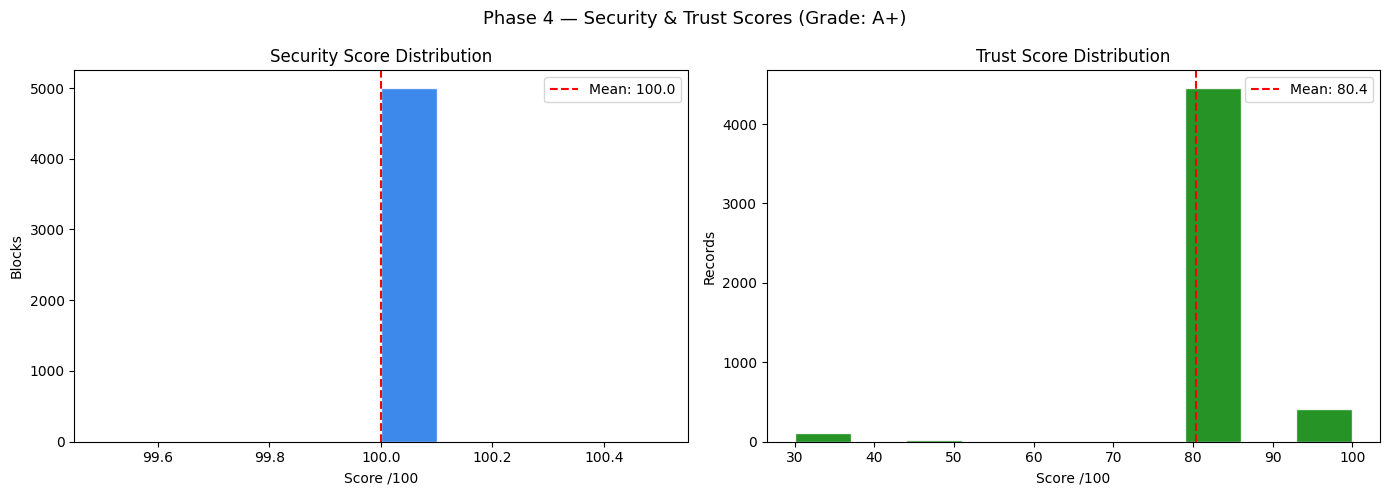

-- Security Score + Trust Score Summary --
   Avg Security Score : 100.0/100 (Grade: A+)
   Min Security Score : 100
   Max Security Score : 100
   Avg Trust Score    : 80.4/100
   Security histogram saved!

-- Per-Record Demo (records 0,1,2) --

Record 0 ("Hindi_character_35_tra"):
   Security Score: 100/100  {'hash_integrity': 40, 'signature_authenticity': 30, 'encryption_present': 15, 'chain_linkage': 15}
   Trust Score   : 100/100  {'recognition_correct': 50, 'integrity_and_authenticity': 30, 'fingerprint_unique': 20}

Record 1 ("Hindi_character_11_taamatar"):
   Security Score: 100/100  {'hash_integrity': 40, 'signature_authenticity': 30, 'encryption_present': 15, 'chain_linkage': 15}
   Trust Score   : 100/100  {'recognition_correct': 50, 'integrity_and_authenticity': 30, 'fingerprint_unique': 20}

Record 2 ("Hindi_digit_1"):
   Security Score: 100/100  {'hash_integrity': 40, 'signature_authenticity': 30, 'encryption_present': 15, 'chain_linkage': 15}
   Trust Score   : 100/100  

In [26]:
# ============================================
# CELL 10F - Security Score + Trust Score + Grade
# ============================================
def compute_security_score(block):
    score, bd = 0, {}
    hash_ok = block.hash == block.compute_hash()
    bd['hash_integrity'] = 40 if hash_ok else 0; score += bd['hash_integrity']
    sig_ok = block.is_signature_valid()
    bd['signature_authenticity'] = 30 if sig_ok else 0; score += bd['signature_authenticity']
    enc_ok = len(block.encrypted_text) > 0
    bd['encryption_present'] = 15 if enc_ok else 0; score += bd['encryption_present']
    chain_idx = next((i for i,b in enumerate(blockchain.chain) if b.index==block.index), None)
    linked_ok = (chain_idx is not None and chain_idx > 0 and
                 block.previous_hash == blockchain.chain[chain_idx-1].hash)
    bd['chain_linkage'] = 15 if linked_ok else 0; score += bd['chain_linkage']
    return score, bd

def compute_trust_score(record, block):
    score, bd = 0, {}
    bd['recognition_correct'] = 50 if record['correct'] else 0; score += bd['recognition_correct']
    integrity_ok = (block.hash == block.compute_hash()) and block.is_signature_valid()
    bd['integrity_and_authenticity'] = 30 if integrity_ok else 0; score += bd['integrity_and_authenticity']
    is_dup = any(d['duplicate_record_id']==record['record_id'] for d in duplicates_found)
    bd['fingerprint_unique'] = 0 if is_dup else 20; score += bd['fingerprint_unique']
    return score, bd

def security_grade(score):
    if score >= 95: return 'A+'
    if score >= 90: return 'A'
    if score >= 80: return 'B+'
    if score >= 70: return 'B'
    if score >= 60: return 'C'
    return 'D'

# Compute for all data blocks
all_sec_scores   = []
all_trust_scores = []
for i, rec in enumerate(records[:min(len(records), len(blockchain.chain)-1)]):
    entry = hash_index.get(str(rec['record_id']))
    if not entry: continue
    block = next((b for b in blockchain.chain if b.index==entry['block_index']), None)
    if not block: continue
    ss, _ = compute_security_score(block)
    ts, _ = compute_trust_score(rec, block)
    all_sec_scores.append(ss)
    all_trust_scores.append(ts)

avg_sec   = sum(all_sec_scores)/len(all_sec_scores)   if all_sec_scores   else 0
avg_trust = sum(all_trust_scores)/len(all_trust_scores) if all_trust_scores else 0
grade     = security_grade(avg_sec)

# Security score histogram
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(all_sec_scores, bins=10, color='#1a73e8', edgecolor='white', alpha=0.85)
axes[0].axvline(avg_sec, color='red', linestyle='--', label=f'Mean: {avg_sec:.1f}')
axes[0].set_title('Security Score Distribution')
axes[0].set_xlabel('Score /100')
axes[0].set_ylabel('Blocks')
axes[0].legend()

axes[1].hist(all_trust_scores, bins=10, color='green', edgecolor='white', alpha=0.85)
axes[1].axvline(avg_trust, color='red', linestyle='--', label=f'Mean: {avg_trust:.1f}')
axes[1].set_title('Trust Score Distribution')
axes[1].set_xlabel('Score /100')
axes[1].set_ylabel('Records')
axes[1].legend()

plt.suptitle(f'Phase 4 — Security & Trust Scores (Grade: {grade})', fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR/'security_scores.png', dpi=150, bbox_inches='tight')
plt.show()

print('-- Security Score + Trust Score Summary --')
print(f'   Avg Security Score : {avg_sec:.1f}/100 (Grade: {grade})')
print(f'   Min Security Score : {min(all_sec_scores) if all_sec_scores else 0}')
print(f'   Max Security Score : {max(all_sec_scores) if all_sec_scores else 0}')
print(f'   Avg Trust Score    : {avg_trust:.1f}/100')
print(f'   Security histogram saved!')

# Demo on 3 records
print(f'\n-- Per-Record Demo (records 0,1,2) --')
for rec_id in [0, 1, 2]:
    rec   = records[rec_id]
    entry = hash_index.get(str(rec_id))
    if not entry: continue
    block = next(b for b in blockchain.chain if b.index==entry['block_index'])
    ss, sb = compute_security_score(block)
    ts, tb = compute_trust_score(rec, block)
    print(f'\nRecord {rec_id} ("{rec["text"]}"):')
    print(f'   Security Score: {ss}/100  {sb}')
    print(f'   Trust Score   : {ts}/100  {tb}')

---
## Cell 10g - Immutable Audit Trail

Every security-relevant action (commit, view, verify) is appended as an
audit entry whose own hash chains to the previous entry - the same
tamper-evidence principle as the main blockchain, applied to the access log
itself, so the audit trail cannot be silently edited after the fact.

   Hash Chain Length   : 9
   Audit Integrity %   : 100.0%


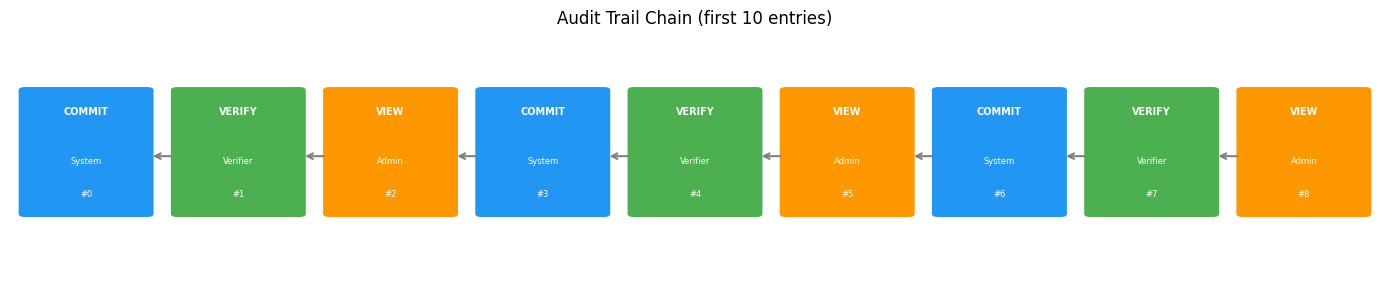

-- Immutable Audit Trail --
   Total entries   : 9
   Chain valid     : True (Audit trail intact)
   Action counts   : {'COMMIT': 3, 'VERIFY': 3, 'VIEW': 3}
   Audit report + visualization saved!


In [32]:
import datetime as dt_module

AUDIT_LOG_PATH = BLOCKCHAIN_DIR / 'audit_log.json'

class AuditTrail:
    def __init__(self, path):
        self.path = Path(path)
        self.entries = []
        if self.path.exists():
            with open(self.path) as f: self.entries = json.load(f)

    def log(self, action, record_id, role='System', detail=''):
        prev_hash = self.entries[-1]['entry_hash'] if self.entries else '0'*64
        entry = {
            'seq': len(self.entries), 'timestamp': str(dt_module.datetime.now()),
            'action': action, 'record_id': record_id,
            'role': role, 'detail': detail, 'prev_hash': prev_hash,
        }
        entry['entry_hash'] = hashlib.sha256(json.dumps(entry, sort_keys=True).encode()).hexdigest()
        self.entries.append(entry)
        return entry

    def save(self):
        with open(self.path, 'w') as f: json.dump(self.entries, f, indent=2)

    def is_valid(self):
        for i in range(1, len(self.entries)):
            e = dict(self.entries[i])
            stored = e.pop('entry_hash')
            if hashlib.sha256(json.dumps(e, sort_keys=True).encode()).hexdigest() != stored:
                return False, f'Audit entry {i} hash mismatch'
            if e['prev_hash'] != self.entries[i-1]['entry_hash']:
                return False, f'Audit entry {i} chain link broken'
        return True, 'Audit trail intact'

audit = AuditTrail(AUDIT_LOG_PATH)
audit.log('COMMIT', 0, 'System',   'Record committed to blockchain')
audit.log('VERIFY', 0, 'Verifier', 'Integrity check performed')
audit.log('VIEW',   0, 'Admin',    'Plaintext viewed via RBAC')
audit.save()

valid, msg = audit.is_valid()

# ── After audit.is_valid(), add these prints ──
audit_integrity_pct = (sum(1 for i in range(1,len(audit.entries))
    if audit.entries[i]['prev_hash']==audit.entries[i-1]['entry_hash'])
    / max(len(audit.entries)-1,1) * 100)

# Audit stats
action_counts = {}
for e in audit.entries:
    action_counts[e['action']] = action_counts.get(e['action'], 0) + 1

# Define audit_report after all components are ready
audit_report = {
    'total_entries'  : len(audit.entries),
    'chain_valid'    : valid,
    'detail'         : msg,
    'action_counts'  : action_counts,
    'integrity_pct'  : round(audit_integrity_pct, 2)
}

with open(OUT_DIR/'security'/'audit_report.json', 'w') as f:
    json.dump(audit_report, f, indent=2)

print(f'   Hash Chain Length   : {audit_report["total_entries"]}')
print(f'   Audit Integrity %   : {audit_report["integrity_pct"]:.1f}%')

# Audit chain visualization
fig, ax = plt.subplots(figsize=(14, 3))
n = min(10, len(audit.entries))
ax.set_xlim(-0.5, n-0.5); ax.set_ylim(-0.5, 2.5); ax.axis('off')
ax.set_title('Audit Trail Chain (first 10 entries)')
colors = {'COMMIT': '#2196F3', 'VERIFY': '#4CAF50', 'VIEW': '#FF9800'}
for i, e in enumerate(audit.entries[:n]):
    c = colors.get(e['action'], '#9E9E9E')
    rect = mpatches.FancyBboxPatch((i-0.4, 0.3), 0.8, 1.5,
        boxstyle='round,pad=0.05', facecolor=c, edgecolor='white', lw=1.5)
    ax.add_patch(rect)
    ax.text(i, 1.5, e['action'], ha='center', color='white', fontsize=7, fontweight='bold')
    ax.text(i, 0.9, e['role'],   ha='center', color='white', fontsize=6)
    ax.text(i, 0.5, f'#{e["seq"]}', ha='center', color='white', fontsize=6)
    if i < n-1:
        ax.annotate('', xy=(i+0.42,1.0), xytext=(i+0.58,1.0),
                    arrowprops=dict(arrowstyle='->', color='gray', lw=1.5))
plt.tight_layout()
plt.savefig(FIG_DIR/'audit_chain.png', dpi=150, bbox_inches='tight')
plt.show()

print('-- Immutable Audit Trail --')
print(f'   Total entries   : {len(audit.entries):,}')
print(f'   Chain valid     : {valid} ({msg})')
print(f'   Action counts   : {action_counts}')
print(f'   Audit report + visualization saved!')

---
## Cell 11 - Decryption + Verification Utility (for Streamlit / Phase 5 reuse)

In [33]:
# ============================================
# CELL 11 - Verification Utility + Report
# ============================================
def verify_and_decrypt_record(record_id, blockchain, hash_index):
    key = str(record_id)
    if key not in hash_index: return None, False, 'record_id not found'
    entry = hash_index[key]
    block = next((b for b in blockchain.chain if b.index==entry['block_index']), None)
    if not block: return None, False, 'block not found'
    if block.hash != block.compute_hash(): return None, False, 'hash mismatch - tampered'
    decrypted = aes_decrypt(block.encrypted_text)
    if hashlib.sha256(decrypted.encode()).hexdigest() != entry['text_sha256']:
        return decrypted, False, 'text hash mismatch - tampered'
    return decrypted, True, 'verified authentic'

verify_rows = []
verify_times_ms = []
success_count = 0

print('-- Verification Utility Demo --')
for rec_id in [0, 1, 2]:
    t0 = time.time()
    text, authentic, info = verify_and_decrypt_record(rec_id, blockchain, hash_index)
    lat = (time.time()-t0)*1000
    verify_times_ms.append(lat)
    if authentic: success_count += 1
    verify_rows.append({'record_id': rec_id, 'authentic': authentic,
                        'latency_ms': round(lat,3), 'info': info})
    print(f'  record_id={rec_id} | text="{text}" | authentic={authentic} | {info}')

avg_verify_lat = sum(verify_times_ms)/len(verify_times_ms)
verify_success_pct = success_count/len(verify_rows)*100

verify_report = {
    'verified_count'    : len(verify_rows),
    'success_count'     : success_count,
    'success_pct'       : round(verify_success_pct, 2),
    'avg_latency_ms'    : round(avg_verify_lat, 3),
}
with open(OUT_DIR/'security'/'verification_report.json', 'w') as f:
    json.dump(verify_report, f, indent=2)

pd.DataFrame(verify_rows).to_csv(OUT_DIR/'evaluation'/'verification_results.csv', index=False)

print(f'\n   Avg Verify Latency  : {avg_verify_lat:.2f} ms')
print(f'   Success Rate        : {verify_success_pct:.1f}%')
print(f'   Verification CSV saved!')
print('---------------------------------')

-- Verification Utility Demo --
  record_id=0 | text="Hindi_character_35_tra" | authentic=True | verified authentic
  record_id=1 | text="Hindi_character_11_taamatar" | authentic=True | verified authentic
  record_id=2 | text="Hindi_digit_1" | authentic=True | verified authentic

   Avg Verify Latency  : 0.10 ms
   Success Rate        : 100.0%
   Verification CSV saved!
---------------------------------


---
## Cell 12 - Final Phase 4 Summary

In [34]:
# ============================================
# CELL 12 - Final Phase 4 Summary + Reports
# ============================================
import platform

EXECUTION_END  = time.time()
total_exec_sec = EXECUTION_END - EXECUTION_START

is_valid_final, _ = blockchain.is_valid()
audit_valid_final, _ = audit.is_valid()
chain_stats = blockchain.get_stats()

# System info
sys_info = {
    'os'             : platform.platform(),
    'python'         : sys.version.split()[0],
    'torch'          : torch.__version__,
    'cuda'           : str(torch.cuda.is_available()),
    'gpu'            : torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None',
    'ram_gb'         : round(psutil.virtual_memory().total/1e9, 1),
    'ram_used_gb'    : round(psutil.virtual_memory().used/1e9, 1),
}

# All results in one JSON
phase4_results = {
    'project_version'     : PROJECT_VERSION,
    'session_id'          : SESSION_ID,
    'execution_start'     : EXECUTION_TS,
    'total_execution_sec' : round(total_exec_sec, 1),
    'system_info'         : sys_info,
    'model_source'        : model_source,
    'model_sha256'        : model_sha256[:24] + '...',
    'recognition'         : recog_stats,
    'blockchain'          : chain_stats,
    'commit'              : commit_stats,
    'validation'          : {'chain_valid': is_valid_final, 'integrity_pct': integrity_pct},
    'security_scores'     : {'avg': round(avg_sec,1), 'grade': grade},
    'trust_scores'        : {'avg': round(avg_trust,1)},
    'audit'               : {'entries': len(audit.entries), 'valid': audit_valid_final},
    'duplicates_found'    : len(duplicates_found),
    'watermark_psnr_db'   : watermark_report['psnr_db'],
    'watermark_ssim'      : watermark_report['ssim'],
    'aes_avg_enc_ms'      : aes_meta['avg_enc_time_ms'],
    'rsa_avg_sign_ms'     : rsa_meta['avg_sign_ms'],
}
with open(OUT_DIR/'evaluation'/'phase4_results.json', 'w') as f:
    json.dump(phase4_results, f, indent=2)
# ── After phase4_results.json save, add dashboard.json ──

# ── NEW: Master Dashboard JSON ─────────────────────
dashboard = {
    'meta': {
        'project'    : PROJECT_VERSION,
        'session_id' : SESSION_ID,
        'generated'  : EXECUTION_TS,
        'exec_sec'   : round(total_exec_sec, 1),
    },
    'system'     : sys_info,
    'recognition': recog_stats,
    'blockchain' : chain_stats,
    'commit'     : commit_stats,
    'validation' : {
        'chain_valid'  : is_valid_final,
        'integrity_pct': integrity_pct,
        'health_score' : health_score,
    },
    'aes'        : aes_meta,
    'rsa'        : rsa_meta,
    'watermark'  : watermark_report,
    'security_scores': {
        'avg'  : round(avg_sec, 1),
        'min'  : min(all_sec_scores) if all_sec_scores else 0,
        'max'  : max(all_sec_scores) if all_sec_scores else 0,
        'grade': grade,
    },
    'trust_scores'   : {'avg': round(avg_trust, 1)},
    'fingerprints'   : {
        'total'        : len(fingerprint_index),
        'duplicates'   : len(duplicates_found),
        'collision_pct': round(collision_pct, 2),
    },
    'audit'          : audit_report,
    'verification'   : verify_report,
}
with open(OUT_DIR/'evaluation'/'dashboard.json', 'w') as f:
    json.dump(dashboard, f, indent=2)

print(f'  Dashboard JSON : {OUT_DIR}/evaluation/dashboard.json')
logger.info(f'Phase 4 complete | exec={total_exec_sec:.1f}s | grade={grade}')
# Summary CSV
summary_rows = [
    ['Total Records Secured', len(records)],
    ['Blockchain Blocks', len(blockchain.chain)],
    ['Chain Valid', is_valid_final],
    ['Integrity %', f'{integrity_pct:.1f}%'],
    ['Sample Accuracy', f'{recog_stats["sample_accuracy"]*100:.2f}%'],
    ['Avg Confidence', f'{recog_stats["avg_confidence"]:.4f}'],
    ['Avg FPS', f'{recog_stats["avg_fps"]:.1f}'],
    ['Avg Security Score', f'{avg_sec:.1f}/100'],
    ['Security Grade', grade],
    ['Avg Trust Score', f'{avg_trust:.1f}/100'],
    ['Duplicates Found', len(duplicates_found)],
    ['Watermark PSNR', f'{watermark_report["psnr_db"]:.2f} dB'],
    ['Watermark SSIM', f'{watermark_report["ssim"]:.6f}'],
    ['Audit Entries', len(audit.entries)],
    ['Audit Valid', audit_valid_final],
    ['AES Avg Enc', f'{aes_meta["avg_enc_time_ms"]:.3f} ms'],
    ['RSA Avg Sign', f'{rsa_meta["avg_sign_ms"]:.2f} ms'],
    ['Total Exec Time', f'{total_exec_sec:.1f} sec'],
]
pd.DataFrame(summary_rows, columns=['Metric', 'Value']).to_csv(
    OUT_DIR/'evaluation'/'phase4_summary.csv', index=False)

# Markdown report
md = f"""# Phase 4 — Blockchain Security Report
**Project**: {PROJECT_VERSION}
**Session**: {SESSION_ID}
**Generated**: {EXECUTION_TS}
**Total Execution**: {total_exec_sec:.1f} sec

## System Info
| Key | Value |
|-----|-------|
| GPU | {sys_info['gpu']} |
| RAM | {sys_info['ram_gb']} GB |
| PyTorch | {sys_info['torch']} |

## Results Summary
| Metric | Value |
|--------|-------|
| Records Secured | {len(records):,} |
| Blockchain Blocks | {len(blockchain.chain):,} |
| Chain Valid | {is_valid_final} |
| Sample Accuracy | {recog_stats['sample_accuracy']*100:.2f}% |
| Avg Security Score | {avg_sec:.1f}/100 ({grade}) |
| Avg Trust Score | {avg_trust:.1f}/100 |
| Duplicates Found | {len(duplicates_found)} |
| Watermark PSNR | {watermark_report['psnr_db']:.2f} dB |
| SSIM | {watermark_report['ssim']:.6f} |

## Security Layers
1. SHA-256 hashing — data integrity
2. AES-256-CBC — confidentiality ({aes_meta['avg_enc_time_ms']:.2f} ms avg)
3. RSA-2048 signatures — authenticity ({rsa_meta['avg_sign_ms']:.2f} ms avg)
4. LSB watermarking — steganographic auth (PSNR={watermark_report['psnr_db']:.1f} dB)
5. RBAC — least-privilege access control
6. Tamper + forgery detection demos
7. Document fingerprinting (collision={len(duplicates_found)})
8. Security Score ({avg_sec:.1f}/100, Grade {grade})
9. Trust Score ({avg_trust:.1f}/100)
10. Immutable audit trail ({len(audit.entries)} entries)
"""
with open(OUT_DIR/'reports'/'phase4_report.md', 'w') as f:
    f.write(md)

# Print final summary
print('\n')
print('='*70)
print('       SecureIndicHTR — PHASE 4 COMPLETE')
print('='*70)
print(f'\nSYSTEM INFO')
print(f'  {"GPU":<30}: {sys_info["gpu"]}')
print(f'  {"RAM":<30}: {sys_info["ram_gb"]} GB')

print(f'\nEXECUTION STATS')
print(f'  {"Total Time":<30}: {total_exec_sec:.1f} sec')
print(f'  {"AES Avg Enc Time":<30}: {aes_meta["avg_enc_time_ms"]:.3f} ms')
print(f'  {"RSA Avg Sign Time":<30}: {rsa_meta["avg_sign_ms"]:.2f} ms')
print(f'  {"Avg Commit Time":<30}: {commit_stats["avg_commit_time_ms"]:.2f} ms')
print(f'  {"Throughput":<30}: {commit_stats["throughput_records_sec"]:.1f} rec/s')

print(f'\nRECOGNITION METRICS')
print(f'  {"Records":<30}: {len(records):,}')
print(f'  {"Sample Accuracy":<30}: {recog_stats["sample_accuracy"]*100:.2f}%')
print(f'  {"Avg Confidence":<30}: {recog_stats["avg_confidence"]:.4f}')
print(f'  {"Avg FPS":<30}: {recog_stats["avg_fps"]:.1f}')

print(f'\nSECURITY METRICS')
print(f'  {"Avg Security Score":<30}: {avg_sec:.1f}/100')
print(f'  {"Security Grade":<30}: {grade}')
print(f'  {"Avg Trust Score":<30}: {avg_trust:.1f}/100')
print(f'  {"Chain Valid":<30}: {is_valid_final}')
print(f'  {"Integrity %":<30}: {integrity_pct:.1f}%')
print(f'  {"Watermark PSNR":<30}: {watermark_report["psnr_db"]:.2f} dB')
print(f'  {"Watermark SSIM":<30}: {watermark_report["ssim"]:.6f}')
print(f'  {"Duplicates Found":<30}: {len(duplicates_found)}')

print(f'\nBLOCKCHAIN METRICS')
print(f'  {"Total Blocks":<30}: {len(blockchain.chain):,}')
print(f'  {"Genesis Hash":<30}: {blockchain.chain[0].hash[:16]}...')
print(f'  {"Latest Hash":<30}: {blockchain.chain[-1].hash[:16]}...')
if chain_stats:
    print(f'  {"Avg Block Size":<30}: {chain_stats.get("avg_block_size_kb",0):.3f} KB')

print(f'\nOUTPUT FILES')
print(f'  Results JSON : {OUT_DIR}/evaluation/phase4_results.json')
print(f'  Summary CSV  : {OUT_DIR}/evaluation/phase4_summary.csv')
print(f'  Report MD    : {OUT_DIR}/reports/phase4_report.md')
print(f'  Figures      : {OUT_DIR}/evaluation/figures/')
print(f'  Security     : {OUT_DIR}/security/')

print('\n')
print('='*70)
print('Ready for Phase 5 - Security Testing Suite!')
print('='*70)
logger.info(f'Phase 4 complete | exec={total_exec_sec:.1f}s | grade={grade}')

  Dashboard JSON : /content/drive/MyDrive/OCR_Project/outputs/evaluation/dashboard.json


       SecureIndicHTR — PHASE 4 COMPLETE

SYSTEM INFO
  GPU                           : Tesla T4
  RAM                           : 13.6 GB

EXECUTION STATS
  Total Time                    : 590.2 sec
  AES Avg Enc Time              : 0.016 ms
  RSA Avg Sign Time             : 1.33 ms
  Avg Commit Time               : 0.00 ms
  Throughput                    : 0.0 rec/s

RECOGNITION METRICS
  Records                       : 5,000
  Sample Accuracy               : 97.40%
  Avg Confidence                : 1.0000
  Avg FPS                       : 247.0

SECURITY METRICS
  Avg Security Score            : 100.0/100
  Security Grade                : A+
  Avg Trust Score               : 80.4/100
  Chain Valid                   : True
  Integrity %                   : 100.0%
  Watermark PSNR                : 68.02 dB
  Watermark SSIM                : 0.999999
  Duplicates Found              : 4566

BLOCKCHA